In [1]:
# imports
import numpy as np 
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import SubplotSpec
import matplotlib.ticker as ticker

In [2]:
def get_gridspec_setup(figsize=(3.54*3, 3.54*2), xlim=None, ylim=None, xlabel='default', ylabel='default', title='default'):
    figure = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 4, figure=figure)
    ax1 = plt.subplot(gs[0, :2], )
    ax2 = plt.subplot(gs[0, 2:])
    ax3 = plt.subplot(gs[1, 1:3])

    axs = [ax1, ax2, ax3]

    if xlim is not None:
        [ax.set_xlim(xlim) for ax in axs]
    if ylim is not None:
        [ax.set_ylim(ylim) for ax in axs]
    if xlabel == 'default':
        [ax.set_xlabel('x [-]') for ax in axs]
    if ylabel == 'default':
        ax1.set_ylabel('$\\varphi$ [-]')
        ax2.set_ylabel('$p$ [-]')
        ax3.set_ylabel('$y_\\alpha$ [-]')
    if title == 'default':
        ax1.set_title('(a)', loc='left')
        ax2.set_title('(b)', loc='left')
        ax3.set_title('(c)', loc='left')

    return figure, ax1, ax2, ax3

In [3]:
def get_gridspec_setup_ParamAna(figsize=(3.54*3, 3.54*2), xlim=None, ylim=None, xlabel='default', ylabel='default', title='default'):
    figure = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 4, figure=figure)
    ax1 = plt.subplot(gs[0, :2], )
    ax2 = plt.subplot(gs[0, 2:])
    ax3 = plt.subplot(gs[1, :2])
    ax4 = plt.subplot(gs[1, 2:])

    axs = [ax1, ax2, ax3, ax4]

    if xlim is not None:
        [ax.set_xlim(xlim) for ax in axs]
    if ylim is not None:
        [ax.set_ylim(ylim) for ax in axs]
    if xlabel == 'default':
        [ax.set_xlabel('x [-]') for ax in axs]
    if title == 'default':
        ax1.set_title('(a)', loc='left')
        ax2.set_title('(b)', loc='left')
        ax3.set_title('(c)', loc='left')
        ax4.set_title('(d)', loc='left')

    return figure, ax1, ax2, ax3, ax4

In [4]:
def get_gridspec_setup_2rows(figsize=(3.54*3, 3.54), xlim=None, ylim=None, xlabel='default', ylabel='default', title='default'):
    figure = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(1, 4, figure=figure)
    ax1 = plt.subplot(gs[0, :2], )
    ax2 = plt.subplot(gs[0, 2:])

    axs = [ax1, ax2]

    if xlim is not None:
        [ax.set_xlim(xlim) for ax in axs]
    if ylim is not None:
        [ax.set_ylim(ylim) for ax in axs]
    if xlabel == 'default':
        [ax.set_xlabel('x [-]') for ax in axs]
    else:
        [ax.set_xlabel(xlabel) for ax in axs]
    if title == 'default':
        ax1.set_title('(a)', loc='left')
        ax2.set_title('(b)', loc='left')

    return figure, ax1, ax2

In [5]:
def create_subtitle(fig: plt.Figure, grid: SubplotSpec, title: str):
    "Sign sets of subplots with title"
    row = fig.add_subplot(grid)
    # the '\n' is important
    # row.set_title(f'{title}\n', fontweight='semibold')
    row.set_title(f'{title}\n\n', fontweight='semibold')
    # hide subplot
    row.set_frame_on(False)
    row.axis('off')

def get_gridspec_setup_Diode(figsize=(3.54*9, 3.54*9), xlabel='default', ylabel='default', subtitlte=True, layout='default'):
    # original problem
    rows = 3
    cols = 5
    if layout == 'default':
        fig, axs = plt.subplots(rows, cols, figsize=(figsize[0]/3, figsize[1]/5))
    elif layout == 'constrained':
        fig, axs = plt.subplots(rows, cols, figsize=(figsize[0]/3, figsize[1]/5), layout='constrained')
    # for i, ax in enumerate(axs.flatten()):
        # ax.set_title(f'Plot title {i}')
    grid = plt.GridSpec(rows, cols)
    if subtitlte:
        create_subtitle(fig, grid[0, ::], 'Forwared Bias')
        create_subtitle(fig, grid[1, ::], 'No Bias')
        create_subtitle(fig, grid[2, ::], 'Backward Bias')
    fig.set_facecolor('w')

    return fig, axs[0], axs[1], axs[2]

In [6]:
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['figure.labelsize'] = 'large'
mpl.rcParams['font.size'] = 12.0
mpl.rcParams['legend.fontsize'] = 'medium'
mpl.rcParams['legend.markerscale'] = 1.0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 4.5
savefig_directory = '../Figures/'
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

In [7]:
markers = ['-', '--', '-.', (0, (3, 5, 1, 5, 1, 5)), ':', (0, (1, 10))]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'black']
marker_phi = markers[0]
marker_p = markers[1]
marker_y_A = markers[0]
marker_y_C = markers[1]
marker_y_S = markers[2]
color_phi = colors[6]
color_p = colors[1]
color_y_A = colors[0]
color_y_C = colors[2]
color_y_S = colors[3]
marker_default = markers[0]
color_default = 'black'

# Shortscomings from classical Nernst-Planck

In [8]:
# load the data
shortcomings_path = '../Data/Shortcomings_NP.npz'
df_shortcomings =  np.load(shortcomings_path)

# extract the data
DeltaPhi_shortcomings = df_shortcomings['DeltaPhi']
x_shortcomings_NP = df_shortcomings['x_NP']
x_shortcomings_Dreyer = df_shortcomings['x_Dreyer']
y_A_shortcomings_NP = df_shortcomings['y_A_NP']
y_A_shortcomings_Dreyer = df_shortcomings['y_A_Dreyer']

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/291929889.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot(x_shortcomings_NP[i], y_A_shortcomings_NP[i], label=f'$\delta \\varphi = {DeltaPhi_shortcomings[i]}$', color=colors[i])
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/291929889.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


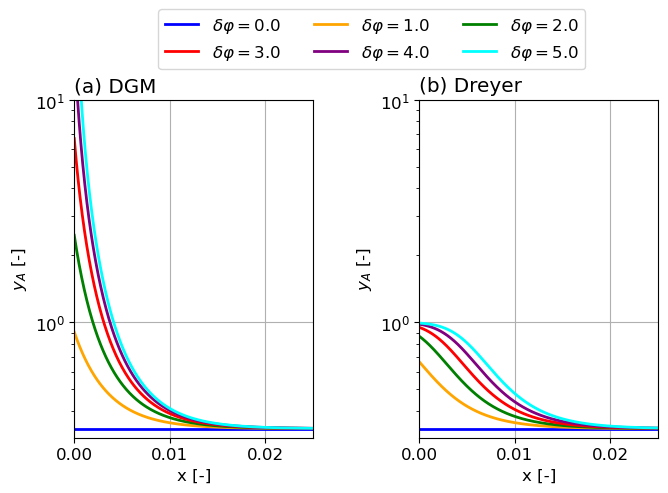

In [9]:
xlim_ = (0, .025)
ylim_ = (1/3-3e-2, 1e+1)
fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*2, 3.54 * 5/4), xlim=xlim_, ylim=ylim_)
ax1.set_title('(a) DGM', loc='left')
ax2.set_title('(b) Dreyer', loc='left')
for i in range(len(DeltaPhi_shortcomings)):
    ax1.plot(x_shortcomings_NP[i], y_A_shortcomings_NP[i], label=f'$\delta \\varphi = {DeltaPhi_shortcomings[i]}$', color=colors[i])
    ax2.plot(x_shortcomings_Dreyer[i], y_A_shortcomings_Dreyer[i], color=colors[i])

[ax.set_ylabel('$y_A$ [-]') for ax in [ax1, ax2]]
[ax.set_yscale('log') for ax in [ax1, ax2]]
order = [0, 3, 1, 4, 2, 5] 
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0.85,1.13), ncol=3)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Shortcomings_NP.pdf', bbox_inches='tight')
fig.show()

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3654324088.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot(x_shortcomings_NP[i], y_A_shortcomings_NP[i], linestyle=markers[i], color=color_default, label=f'$\delta \\varphi = {DeltaPhi_shortcomings[i]}$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3654324088.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


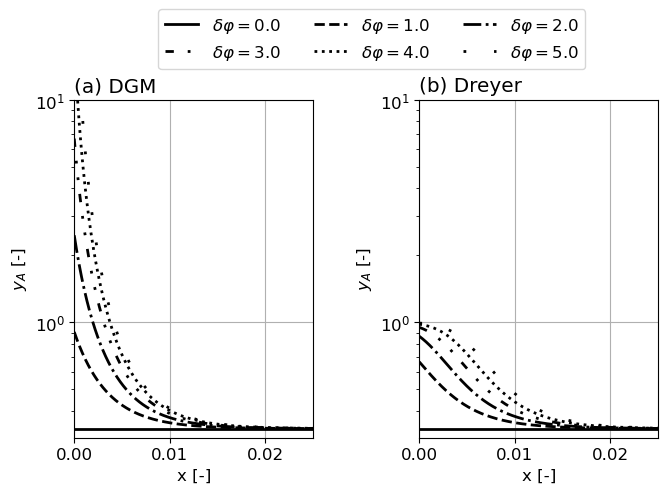

In [10]:
xlim_ = (0, .025)
ylim_ = (1/3-3e-2, 1e+1)
fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*2, 3.54 * 5/4), xlim=xlim_, ylim=ylim_)
ax1.set_title('(a) DGM', loc='left')
ax2.set_title('(b) Dreyer', loc='left')
for i in range(len(DeltaPhi_shortcomings)):
    ax1.plot(x_shortcomings_NP[i], y_A_shortcomings_NP[i], linestyle=markers[i], color=color_default, label=f'$\delta \\varphi = {DeltaPhi_shortcomings[i]}$')
    ax2.plot(x_shortcomings_Dreyer[i], y_A_shortcomings_Dreyer[i], linestyle=markers[i], color=color_default)

[ax.set_ylabel('$y_A$ [-]') for ax in [ax1, ax2]]
[ax.set_yscale('log') for ax in [ax1, ax2]]
order = [0, 3, 1, 4, 2, 5] 
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0.85,1.13), ncol=3)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Shortcomings_NP_linestyles.pdf', bbox_inches='tight')
fig.show()

# Validation with Dreyer

In [11]:
# Load the JSON data
file_path = '../Data/ValidDreyer.json'  # Update this path if needed
with open(file_path, 'r') as file:
    data = json.load(file)

In [12]:
# Extract the data and store it in a dictionary
data_Dreyer = {}
for data_point in data['datasetColl']:
    x, y = [], []
    for i in range(len(data_point['data'])):
        x.append(data_point['data'][i]['value'][0])
        y.append(data_point['data'][i]['value'][1])
    data_Dreyer[data_point['name']] = (np.array(x), np.array(y))

In [13]:
# load the data
dreyer_path = '../Data/Validation_Dreyer_BulkSurface.npz'
df_dreyer =  np.load(dreyer_path)

# extract the data
x_dreyer = df_dreyer['x_dim']
n_A_dreyer = df_dreyer['n_A_dim']
n_C_dreyer = df_dreyer['n_C_dim']
phi_dreyer = df_dreyer['phi_dim']
p_dreyer = df_dreyer['p_dim']
p_dreyer_MP = p_dreyer * 1e-6

<>:3: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\k'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/54330222.py:3: SyntaxWarning: invalid escape sequence '\k'
  labels = ['ideal mixture, $\kappa = 0$', 'solvated ions, $\kappa = 8$', 'NP']
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/54330222.py:3: SyntaxWarning: invalid escape sequence '\k'
  labels = ['ideal mixture, $\kappa = 0$', 'solvated ions, $\kappa = 8$', 'NP']
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/54330222.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/54330222.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


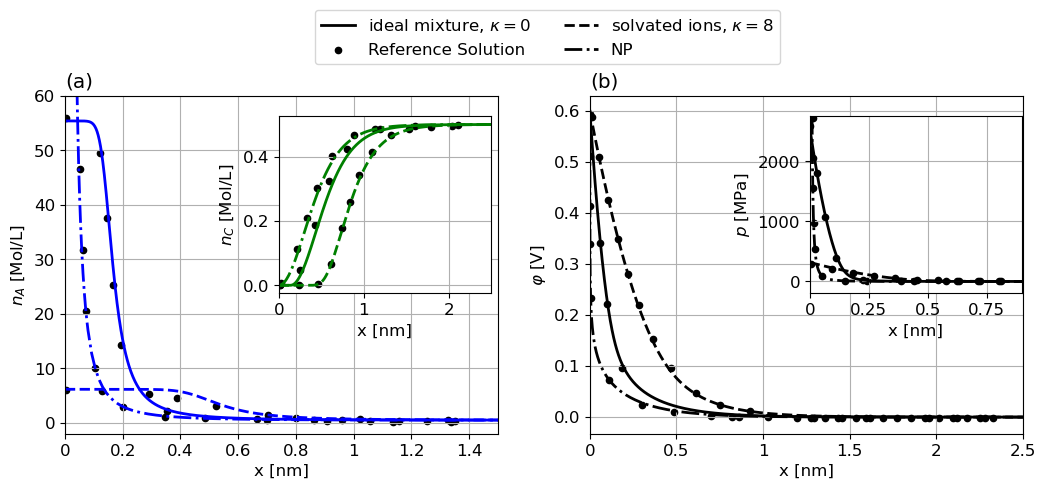

In [14]:
scale_x = 1e-9
ticks_x = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/scale_x))
labels = ['ideal mixture, $\kappa = 0$', 'solvated ions, $\kappa = 8$', 'NP']

fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4))

a_n_C = plt.axes([.27, .46, .2, .4])

a_p = plt.axes([.77, .46, .2, .4])

axs = [ax1, a_n_C, ax2, a_p]

for i in range(3):
    axs[0].plot(x_dreyer[i], n_A_dreyer[i], color=color_y_A, linestyle=markers[i])
    axs[1].plot(x_dreyer[i], n_C_dreyer[i], color=color_y_C, linestyle=markers[i])
    axs[2].plot(x_dreyer[i], phi_dreyer[i], color=color_default, linestyle=markers[i], label=labels[i])
    axs[3].plot(x_dreyer[i], p_dreyer_MP[i], color=color_default, linestyle=markers[i])

color_Dreyer = 'black'
marker_Dreyer_Solvated = "o"
marker_Dreyer_Ideal = "o"
marker_Dreyer_PB = "o"
skip_Dreyer = 8
axs[0].scatter(data_Dreyer['Solvated Anions'][0][::skip_Dreyer]*1e-9, data_Dreyer['Solvated Anions'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Solvated, label='Reference Solution')
axs[0].scatter(data_Dreyer['Ideal Anions'][0][::skip_Dreyer]*1e-9, data_Dreyer['Ideal Anions'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Ideal)
axs[0].scatter(data_Dreyer['PB-Anions'][0][::skip_Dreyer]*1e-9, data_Dreyer['PB-Anions'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_PB)
axs[1].scatter(data_Dreyer['Solvated Cations'][0][::skip_Dreyer]*1e-9, data_Dreyer['Solvated Cations'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Solvated)
axs[1].scatter(data_Dreyer['Ideal Cations'][0][::skip_Dreyer]*1e-9, data_Dreyer['Ideal Cations'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Ideal)
axs[1].scatter(data_Dreyer['PB-Cations'][0][::skip_Dreyer]*1e-9, data_Dreyer['PB-Cations'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_PB)
axs[2].scatter(data_Dreyer['Solvated Potential'][0][::skip_Dreyer]*1e-9, data_Dreyer['Solvated Potential'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Solvated)
axs[2].scatter(data_Dreyer['Ideal Potential'][0][::skip_Dreyer]*1e-9, data_Dreyer['Ideal Potential'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Ideal)
axs[2].scatter(data_Dreyer['PB-Potential'][0][::skip_Dreyer]*1e-9, data_Dreyer['PB-Potential'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_PB)
axs[3].scatter(data_Dreyer['Solvated Pressure'][0][::skip_Dreyer]*1e-9, data_Dreyer['Solvated Pressure'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Solvated)
axs[3].scatter(data_Dreyer['Ideal Pressure'][0][::skip_Dreyer]*1e-9, data_Dreyer['Ideal Pressure'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_Ideal)
axs[3].scatter(data_Dreyer['PB-Pressure'][0][::skip_Dreyer]*1e-9, data_Dreyer['PB-Pressure'][1][::skip_Dreyer], color=color_Dreyer, marker=marker_Dreyer_PB)

[ax.set_xlabel('x [nm]') for ax in axs]
axs[0].set_ylabel('$n_A$ [Mol/L]')
axs[1].set_ylabel('$n_C$ [Mol/L]')
axs[2].set_ylabel('$\\varphi$ [V]')
axs[3].set_ylabel('$p$ [MPa]')
axs[0].set_xlim(0,1.5*scale_x)
axs[1].set_xlim(0,2.5*scale_x)
axs[2].set_xlim(0,2.5*scale_x)
axs[3].set_xlim(0,0.9*scale_x)
# axs[3].set_ylim(0, np.max(p_dreyer[1])*1.1)
[ax.xaxis.set_major_formatter(ticks_x) for ax in axs]
axs[0].set_ylim(-2,60)
axs[3].set_ylim(-200,2750) # (0, 2750)

# fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.52, 1.05))
order = [1, 0, 2, 3] 
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0.75,1.12), ncol=2)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/ValidationDreyerPaper.pdf', bbox_inches='tight')
fig.show()

## Ternary Electrolyte

In [15]:
# load the data
ternary_path = '../Data/TernaryElectrolyte.npz'
df_ternary =  np.load(ternary_path)

# extract the data
x_ternary = df_ternary['x']
phi_ternary = df_ternary['phi']
p_ternary = df_ternary['p']
y_A_ternary = df_ternary['y_A']
y_C_ternary = df_ternary['y_C']
y_S_ternary = 1 - y_A_ternary - y_C_ternary
index_ternary = df_ternary['index']
nF_ternary = df_ternary['nF']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1927661803.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


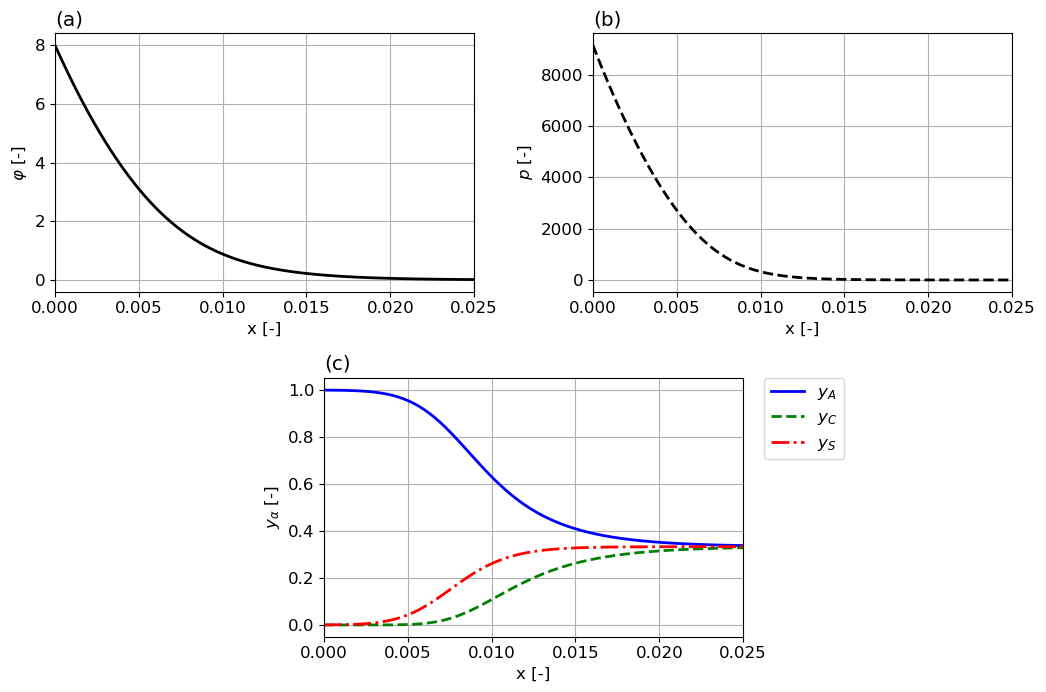

In [16]:
xlim_ = (0, 0.025)

fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
ax1.plot(x_ternary, phi_ternary, linestyle=marker_phi, color=color_default)
ax2.plot(x_ternary, p_ternary, linestyle=marker_p, color=color_default)
ax3.plot(x_ternary, y_A_ternary, linestyle=marker_y_A, color=color_y_A, label='$y_A$')
ax3.plot(x_ternary, y_C_ternary, linestyle=marker_y_C, color=color_y_C, label='$y_C$')
ax3.plot(x_ternary, y_S_ternary, linestyle=marker_y_S, color=color_y_S, label='$y_S$')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

fig.tight_layout()
fig.savefig(f'{savefig_directory}/TernaryElectrolyte.pdf', bbox_inches='tight')
fig.show()

## Parameteranalysis

In [17]:
# load the data
ParamAna_path = '../Data/ParameterAnalysis/Lambda.npz'
df_ParamAna = np.load(ParamAna_path)

# extract the data
x_ParamAna = df_ParamAna['x']
phi_ParamAna = df_ParamAna['phi']
p_ParamAna = df_ParamAna['p']
y_A_ParamAna = df_ParamAna['y_A']
y_C_ParamAna = df_ParamAna['y_C']
y_S_ParamAna = 1 - y_A_ParamAna - y_C_ParamAna
phi_left_vec_ParamAna = df_ParamAna['phi_left_vec']
Lambda2_vec_ParamAna = df_ParamAna['Lambda2_vec']

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3580878440.py:13: SyntaxWarning: invalid escape sequence '\l'
  dummy, = axs[0].plot([], [], color=colors[j], label=f'$\lambda^2$ = {Lambda2}')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3580878440.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


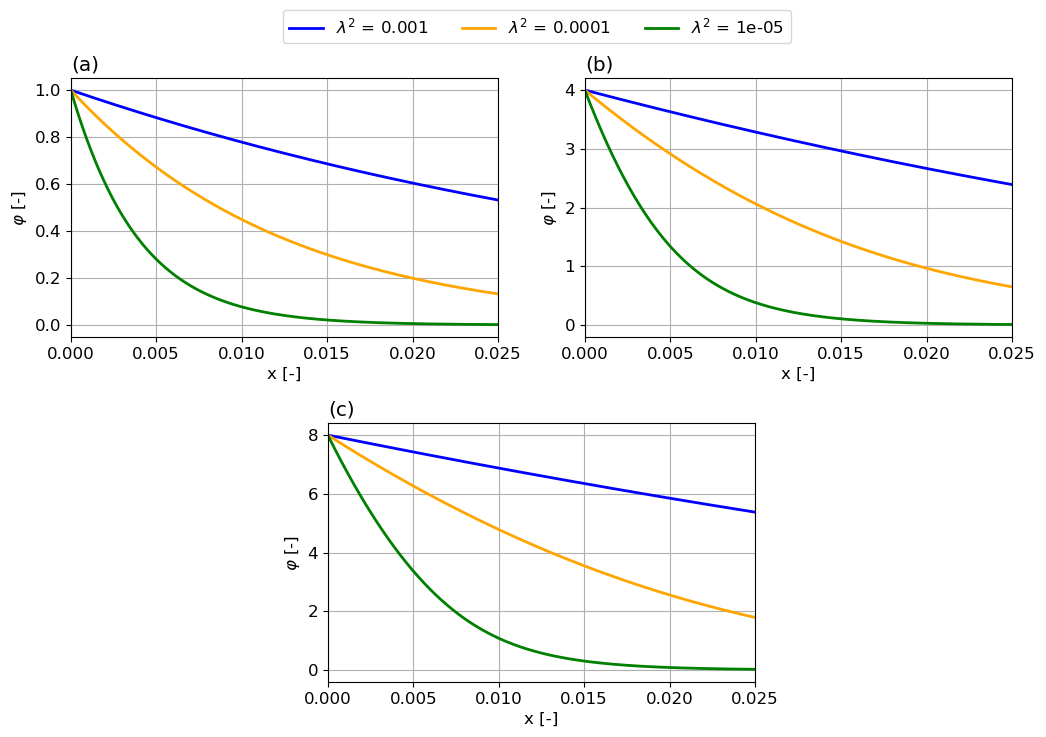

In [18]:
xlim_ = (0, 0.025)

# fig, ax1, ax2, ax3, ax4 = get_gridspec_setup_ParamAna(xlim=xlim_)
fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
axs = [ax1, ax2, ax3]
title_ = ['a)', 'b)', 'c)']
for i, phi_left in enumerate(phi_left_vec_ParamAna):
    for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
        axs[i].plot(x_ParamAna[i][j], phi_ParamAna[i][j], color=colors[j])


for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
    dummy, = axs[0].plot([], [], color=colors[j], label=f'$\lambda^2$ = {Lambda2}')

[ax.set_ylabel(f'$\\varphi$ [-]') for i, ax in enumerate(axs)]
lgnd = fig.legend(bbox_to_anchor=(0.76,1.05), ncol=3)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/ParameterAnalysis/potential.pdf', bbox_inches='tight')
fig.show()

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/4001125051.py:8: SyntaxWarning: invalid escape sequence '\l'
  dummy, = axs[0].plot([], [], color=colors[j], label=f'$\lambda^2$ = {Lambda2}')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/4001125051.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


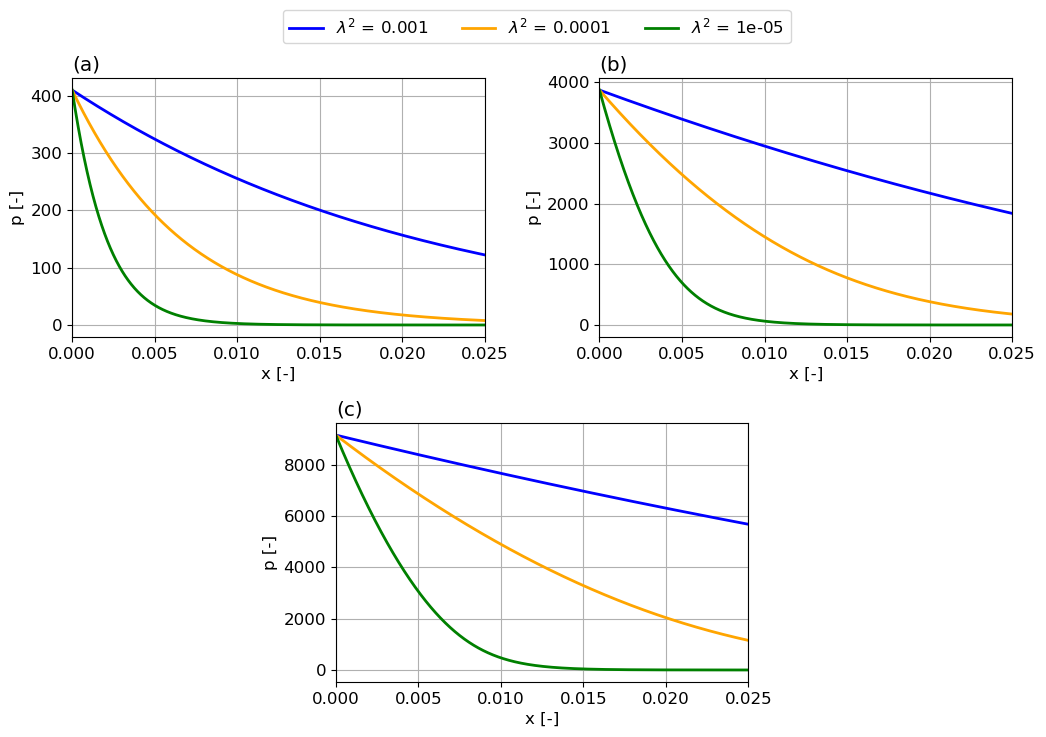

In [19]:
fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
axs = [ax1, ax2, ax3]
for i, phi_left in enumerate(phi_left_vec_ParamAna):
    for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
        axs[i].plot(x_ParamAna[i][j], p_ParamAna[i][j], color=colors[j])

for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
    dummy, = axs[0].plot([], [], color=colors[j], label=f'$\lambda^2$ = {Lambda2}')

[ax.set_ylabel(f'p [-]') for i, ax in enumerate(axs)]
lgnd = fig.legend(bbox_to_anchor=(0.76,1.05), ncol=3)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/ParameterAnalysis/pressure.pdf', bbox_inches='tight')
fig.show()

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1685350047.py:11: SyntaxWarning: invalid escape sequence '\l'
  dummy, = axs[0].plot([], [], linestyle=marker_default, color=colors[j], label=f'$\lambda^2$ = {Lambda2}')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1685350047.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


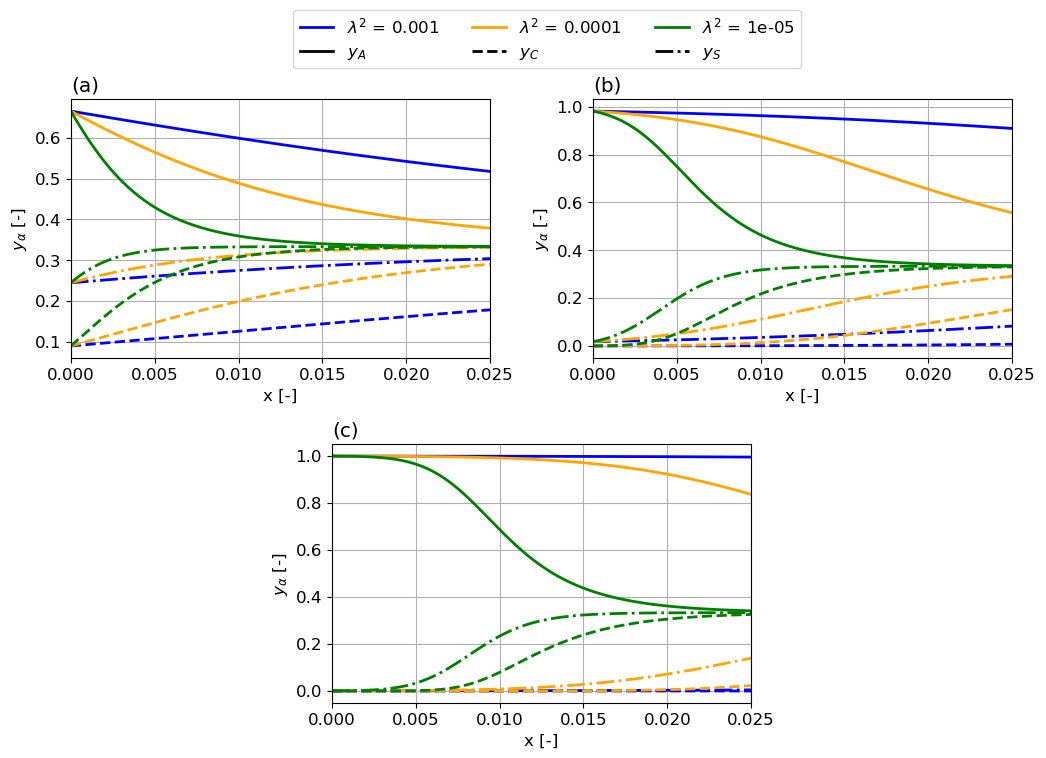

In [20]:
fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
axs = [ax1, ax2, ax3]
for i, phi_left in enumerate(phi_left_vec_ParamAna):
    for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
        axs[i].plot(x_ParamAna[i][j], y_A_ParamAna[i][j], linestyle=marker_y_A, color=colors[j])
        axs[i].plot(x_ParamAna[i][j], y_C_ParamAna[i][j], linestyle=marker_y_C, color=colors[j])
        axs[i].plot(x_ParamAna[i][j], y_S_ParamAna[i][j], linestyle=marker_y_S, color=colors[j])


for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
    dummy, = axs[0].plot([], [], linestyle=marker_default, color=colors[j], label=f'$\lambda^2$ = {Lambda2}')
for ls, label in zip([marker_y_A, marker_y_C, marker_y_S], ['$y_A$', '$y_C$', '$y_S$']):
    dummy, = axs[0].plot([], [], linestyle=ls, color=color_default, label=label)

[ax.set_ylabel(f'$y_\\alpha$ [-]') for i, ax in enumerate(axs)]

order = [0, 3, 1, 4, 2, 5] 
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0.77,1.08), ncol=3)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/ParameterAnalysis/fractions.pdf', bbox_inches='tight')
fig.show()

### Scale $\varphi$

In [21]:
df_scale_phi_path = '../Data/ParameterAnalysis/ScalingPhi.npz'
df_scale_phi = np.load(df_scale_phi_path)

phi_left_vector_scale_phi = df_scale_phi['phi_left_vector']
phi_scale_phi = df_scale_phi['phi']
phi_scaled_scale_phi = df_scale_phi['phi_scaled']
x_scale_phi = df_scale_phi['x']

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2862050134.py:3: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot(x_scale_phi[i], phi_scale_phi[i], linestyle=marker_default, color=colors[i], label=f'$\delta \\varphi = {phi_left}$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2862050134.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_ylabel('$\\varphi/\delta \\varphi$ [-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2862050134.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


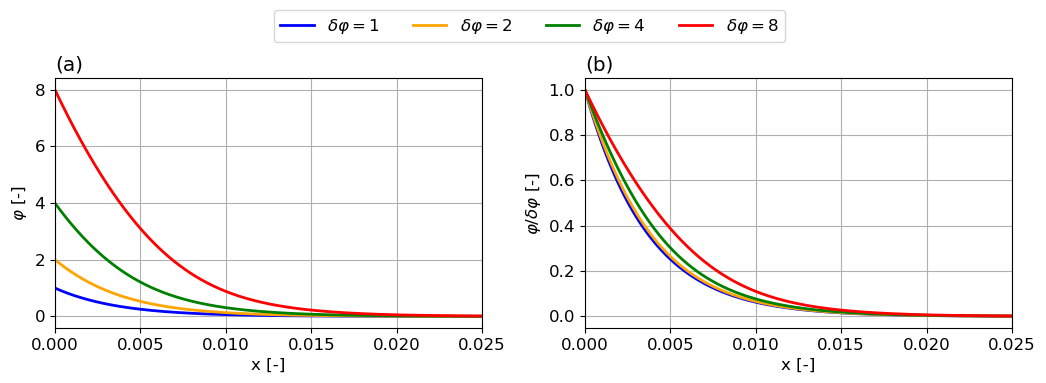

In [22]:
fig, ax1, ax2 = get_gridspec_setup_2rows(xlim=xlim_)
for i, phi_left in enumerate(phi_left_vector_scale_phi):
    ax1.plot(x_scale_phi[i], phi_scale_phi[i], linestyle=marker_default, color=colors[i], label=f'$\delta \\varphi = {phi_left}$')
    ax2.plot(x_scale_phi[i], phi_scaled_scale_phi[i], linestyle=marker_default, color=colors[i])

ax1.set_ylabel('$\\varphi$ [-]')
ax2.set_ylabel('$\\varphi/\delta \\varphi$ [-]')
lgnd = fig.legend(bbox_to_anchor=(0.755,1.1), ncol=4)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/ParameterAnalysis/scaled_potential.pdf', bbox_inches='tight')
fig.show()

### Atomic Fractions at Electrode ($y_\alpha^L(\varphi^L)$)

In [23]:
df_fractions_electrode_path = '../Data/ParameterAnalysis/FractionsHeightLeft.npz'
df_fractions_electrode = np.load(df_fractions_electrode_path)

phi_left_vector_fractions_electrode = df_fractions_electrode['phi_left_vec']
y_A_fractions_electrode = df_fractions_electrode['y_A']
y_C_fractions_electrode = df_fractions_electrode['y_C']
y_S_fractions_electrode = df_fractions_electrode['y_S']

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2540293114.py:4: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2540293114.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_fractions_electrode.show()


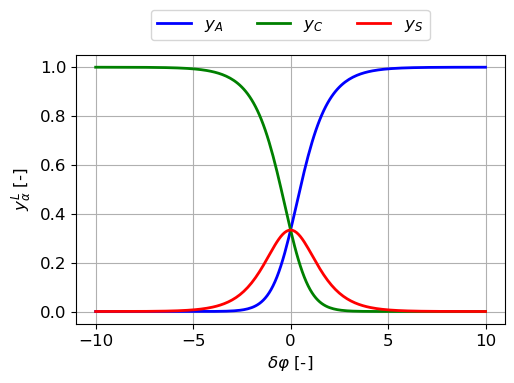

In [24]:
fig_fractions_electrode, axs = plt.subplots(1, 1, figsize=(3.54*3/2, 3.54))
for property_, color_, label_ in zip([y_A_fractions_electrode, y_C_fractions_electrode, y_S_fractions_electrode], [color_y_A, color_y_C, color_y_S], ['$y_A$', '$y_C$', '$y_S$']):
    axs.plot(phi_left_vector_fractions_electrode, property_[:,0], linestyle=marker_default, color=color_, label=label_)
axs.set_xlabel('$\delta \\varphi$ [-]')
axs.set_ylabel('$y_\\alpha^L$ [-]')
axs.tick_params(axis='both')

lgnd = fig_fractions_electrode.legend(bbox_to_anchor=(0.84,1.1), ncol=3)
fig_fractions_electrode.tight_layout()
fig.savefig(f'{savefig_directory}/ParameterAnalysis/fractions_at_electrode.pdf', bbox_inches='tight')
fig_fractions_electrode.show()

## Comparison to classical Nernst-Planck model

### Single plots

In [25]:
# Potential of 1 [-]
df_NP_1_path = '../Data/PoissonBoltzmann_1.npz'
df_NP_1 = np.load(df_NP_1_path)

# DGM
x_DGM_1 = df_NP_1['x_DGM_01']
phi_DGM_1 = df_NP_1['phi_DGM_01']
p_DGM_1 = df_NP_1['p_DGM_01']
y_A_DGM_1 = df_NP_1['y_A_DGM_01']
y_C_DGM_1 = df_NP_1['y_C_DGM_01']
y_S_DGM_1 = df_NP_1['y_S_DGM_01']
# NP
x_NP_1 = df_NP_1['x_PB_01']
phi_NP_1 = df_NP_1['phi_PB_01']
p_NP_1 = df_NP_1['p_PB_01']
y_A_NP_1 = df_NP_1['y_A_PB_01']
y_C_NP_1 = df_NP_1['y_C_PB_01']
y_S_NP_1 = df_NP_1['y_S_PB_01']

# Potential of 10 [-]
df_NP_10_path = '../Data/PoissonBoltzmann_10.npz'
df_NP_10 = np.load(df_NP_10_path)

# DGM
x_DGM_10 = df_NP_10['x_DGM_10']
phi_DGM_10 = df_NP_10['phi_DGM_10']
p_DGM_10 = df_NP_10['p_DGM_10']
y_A_DGM_10 = df_NP_10['y_A_DGM_10']
y_C_DGM_10 = df_NP_10['y_C_DGM_10']
y_S_DGM_10 = df_NP_10['y_S_DGM_10']
# NP
x_NP_10 = df_NP_10['x_PB_10']
phi_NP_10 = df_NP_10['phi_PB_10']
p_NP_10 = df_NP_10['p_PB_10']
y_A_NP_10 = df_NP_10['y_A_PB_10']
y_C_NP_10 = df_NP_10['y_C_PB_10']
y_S_NP_10 = df_NP_10['y_S_PB_10']

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/190523336.py:5: SyntaxWarning: invalid escape sequence '\d'
  for property_DGM, property_NP, label_ in zip([phi_DGM_1, phi_DGM_10], [phi_NP_1, phi_NP_10], ['$\delta \\varphi = 1$', '$\delta \\varphi = 10$']):
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/190523336.py:5: SyntaxWarning: invalid escape sequenc

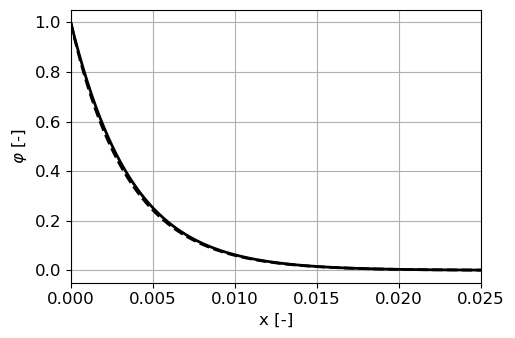

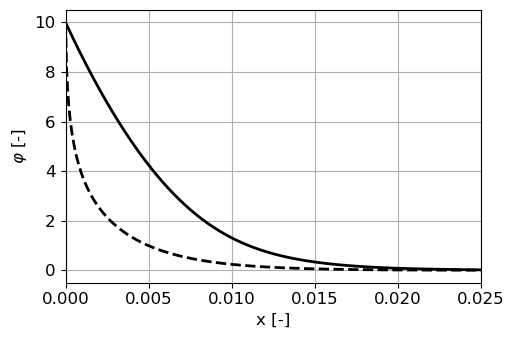

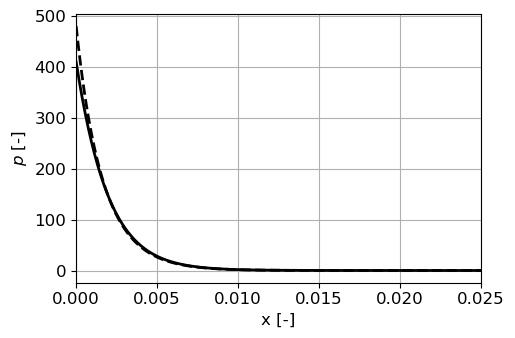

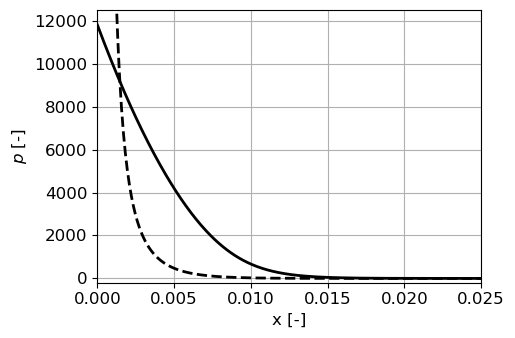

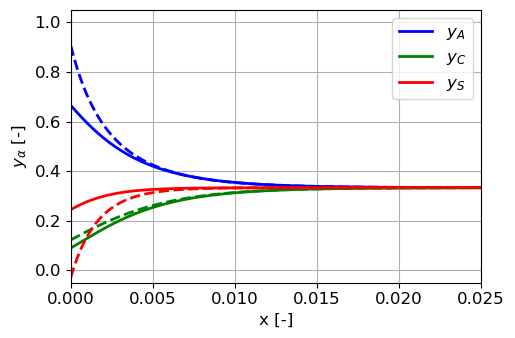

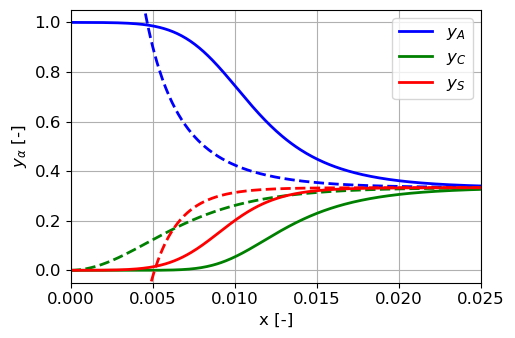

In [26]:
xlim_ = (0, 0.025)
marker_DGM = marker_default
marker_NP = markers[1]

for property_DGM, property_NP, label_ in zip([phi_DGM_1, phi_DGM_10], [phi_NP_1, phi_NP_10], ['$\delta \\varphi = 1$', '$\delta \\varphi = 10$']):
    fig, axs = plt.subplots(1, 1, figsize=(3.54*3/2, 3.54))

    axs.plot(x_DGM_1, property_DGM, linestyle=marker_DGM, color=color_default, label=label_)
    axs.plot(x_NP_1, property_NP, linestyle=marker_NP, color=color_default)

    axs.set_xlabel('x [-]')
    axs.set_ylabel('$\\varphi$ [-]')
    axs.set_xlim(xlim_)

    fig.tight_layout()
    fig.savefig(f'{savefig_directory}/ComparisonNernstPlanck/potential_{label_}.pdf', bbox_inches='tight')
    fig.show()

for i, (property_DGM, property_NP, label_) in enumerate(zip([p_DGM_1, p_DGM_10], [p_NP_1, p_NP_10], ['$\delta \\varphi = 1$', '$\delta \\varphi = 10$'])):
    fig, axs = plt.subplots(1, 1, figsize=(3.54*3/2, 3.54))

    axs.plot(x_DGM_1, property_DGM, linestyle=marker_DGM, color=color_default, label=label_)
    axs.plot(x_NP_1, property_NP, linestyle=marker_NP, color=color_default)

    axs.set_xlabel('x [-]')
    axs.set_ylabel('$p$ [-]')
    axs.set_xlim(xlim_)

    if i==1:
        axs.set_ylim(-200, 12_500)

    fig.tight_layout()
    fig.savefig(f'{savefig_directory}/ComparisonNernstPlanck/pressure_{label_}.pdf', bbox_inches='tight')
    fig.show()

for property_A_DGM, property_A_NP, property_C_DGM, property_C_NP, property_S_DGM, property_S_NP, label_ in zip([y_A_DGM_1, y_A_DGM_10], [y_A_NP_1, y_A_NP_10], [y_C_DGM_1, y_C_DGM_10], [y_C_NP_1, y_C_NP_10], [y_S_DGM_1, y_S_DGM_10], [y_S_NP_1, y_S_NP_10], ['$\delta \\varphi = 1$', '$\delta \\varphi = 10$']):
    fig, axs = plt.subplots(1, 1, figsize=(3.54*3/2, 3.54))

    for property_DGM, property_NP, color_, label in zip([property_A_DGM, property_C_DGM, property_S_DGM], [property_A_NP, property_C_NP, property_S_NP], [color_y_A, color_y_C, color_y_S], ['$y_A$', '$y_C$', '$y_S$']):
        axs.plot(x_DGM_1, property_DGM, linestyle=marker_DGM, color=color_, label=label)
        axs.plot(x_NP_1, property_NP, linestyle=marker_NP, color=color_)

    lb = -.05
    ub = 1.05
    axs.set_xlabel('x [-]')
    axs.set_ylabel('$y_\\alpha$ [-]')
    axs.set_xlim(xlim_)
    axs.set_ylim(lb, ub)
    axs.legend()

    fig.tight_layout()
    fig.savefig(f'{savefig_directory}/ComparisonNernstPlanck/fractions_{label_}.pdf', bbox_inches='tight')
    fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1353228104.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


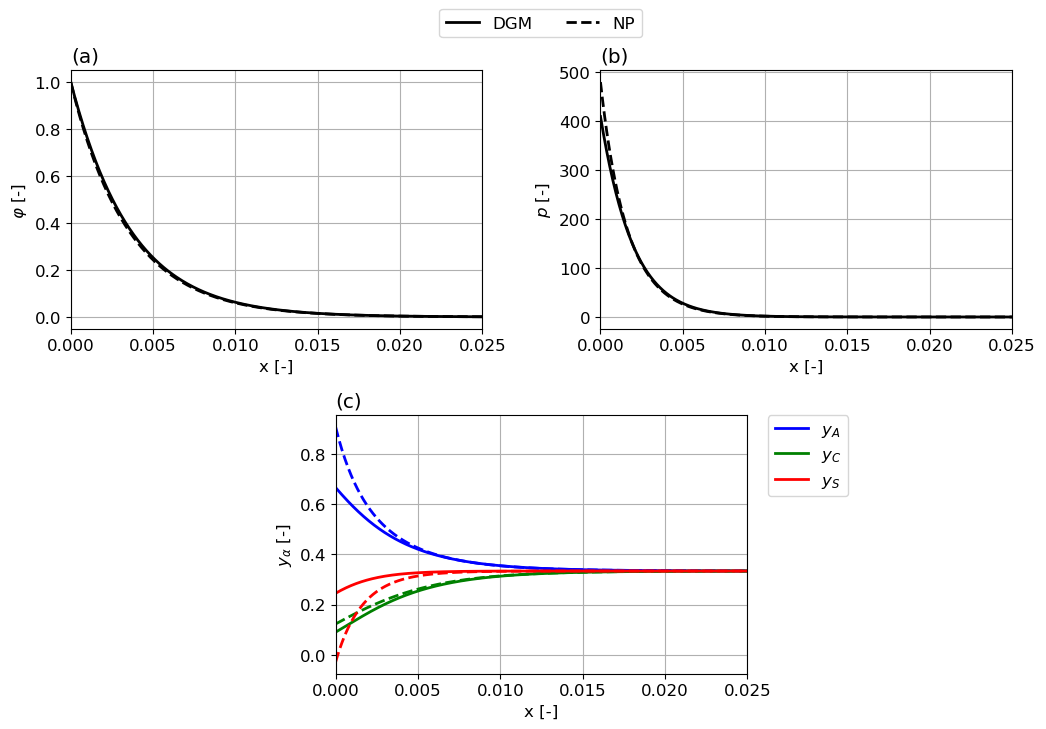

In [27]:
xlim_ = (0, 0.025)
marker_DGM = marker_default
marker_NP = markers[1]
fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
ax1.plot(x_DGM_1, phi_DGM_1, linestyle=marker_DGM, color=color_default, label='DGM')
ax1.plot(x_NP_1, phi_NP_1, linestyle=marker_NP, color=color_default, label='NP')
ax2.plot(x_DGM_1, p_DGM_1, linestyle=marker_DGM, color=color_default)
ax2.plot(x_NP_1, p_NP_1, linestyle=marker_NP, color=color_default)
ax3.plot(x_DGM_1, y_A_DGM_1, linestyle=marker_DGM, color=color_y_A, label='$y_A$')
ax3.plot(x_NP_1, y_A_NP_1, linestyle=marker_NP, color=color_y_A)
ax3.plot(x_DGM_1, y_C_DGM_1, linestyle=marker_DGM, color=color_y_C, label='$y_C$')
ax3.plot(x_NP_1, y_C_NP_1, linestyle=marker_NP, color=color_y_C)
ax3.plot(x_DGM_1, y_S_DGM_1, linestyle=marker_DGM, color=color_y_S, label='$y_S$')
ax3.plot(x_NP_1, y_S_NP_1, linestyle=marker_NP, color=color_y_S)

# ToDo: Center the second legend line
order = [0, 1]
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], 
bbox_to_anchor=(0.62,1.04), ncol=5)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

fig.tight_layout()
fig.savefig(f'{savefig_directory}/ComparisonNernstPlanck/potential_01.pdf', bbox_inches='tight')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1871913435.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


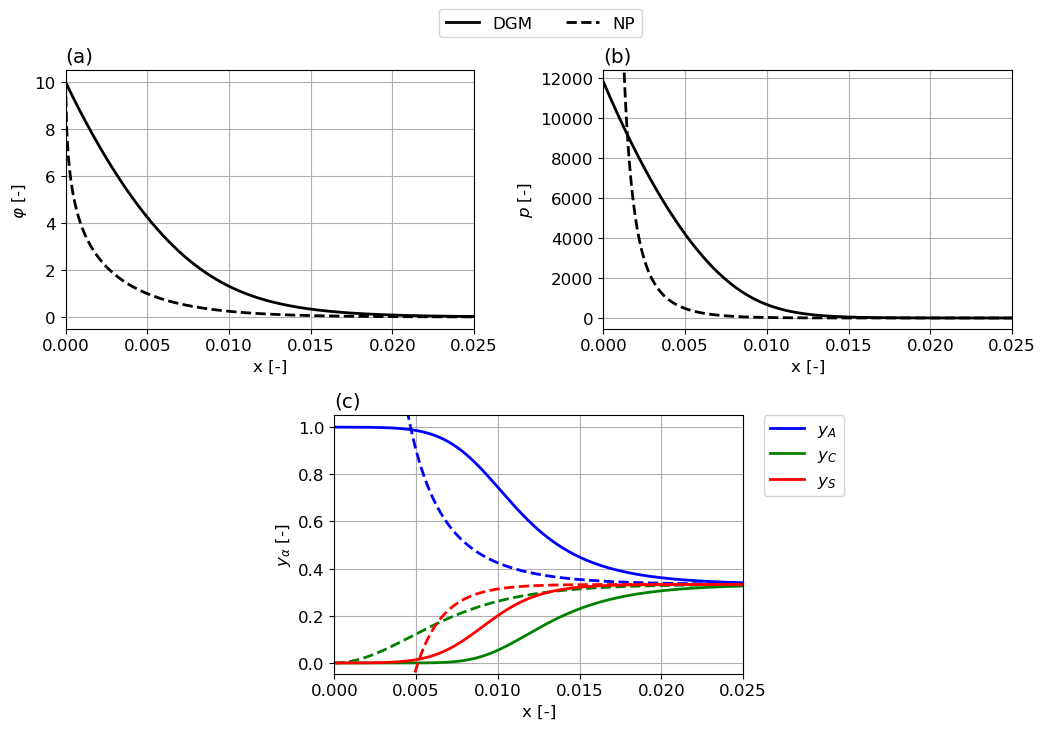

In [28]:
fig, ax1, ax2, ax3 = get_gridspec_setup(xlim=xlim_)
ax1.plot(x_DGM_10, phi_DGM_10, linestyle=marker_DGM, color=color_default, label='DGM')
ax1.plot(x_NP_10, phi_NP_10, linestyle=marker_NP, color=color_default, label='NP')
ax2.plot(x_DGM_10, p_DGM_10, linestyle=marker_DGM, color=color_default)
ax2.plot(x_NP_10, p_NP_10, linestyle=marker_NP, color=color_default)
ax3.plot(x_DGM_10, y_A_DGM_10, linestyle=marker_DGM, color=color_y_A, label='$y_A$')
ax3.plot(x_NP_10, y_A_NP_10, linestyle=marker_NP, color=color_y_A)
ax3.plot(x_DGM_10, y_C_DGM_10, linestyle=marker_DGM, color=color_y_C, label='$y_C$')
ax3.plot(x_NP_10, y_C_NP_10, linestyle=marker_NP, color=color_y_C)
ax3.plot(x_DGM_10, y_S_DGM_10, linestyle=marker_DGM, color=color_y_S, label='$y_S$')
ax3.plot(x_NP_10, y_S_NP_10, linestyle=marker_NP, color=color_y_S)

for marker, label in zip([marker_phi, marker_p, marker_y_A, marker_y_C, marker_y_S], ['$\\varphi$ [-]', '$p$ [-]', '$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
    dummy, = ax1.plot([], [], linestyle=marker, color=color_default, label=label)
for _ in range(3):
    dummy, = ax1.plot([], [], linestyle='-', color=color_default, label='')

# ToDo: Center the second legend line
order = [0, 1]
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], 
bbox_to_anchor=(0.62,1.04), ncol=5)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adapt the yscale for the pressure according to the potential
lower_limit_phi = ax1.get_ylim()[0]
upper_limit_phi = ax1.get_ylim()[1]
upper_limit_phi_ratio = upper_limit_phi / np.max(phi_DGM_10)
phi_extra_added = (upper_limit_phi - lower_limit_phi) - (np.max(phi_DGM_10) - np.min(phi_DGM_10))
phi_extra_added_fraction = phi_extra_added / (upper_limit_phi - lower_limit_phi)
lower_limit_phi, upper_limit_phi, upper_limit_phi_ratio, phi_extra_added, phi_extra_added_fraction
ax2.set_ylim(-phi_extra_added_fraction/2*(np.max(p_DGM_10) - np.min(p_DGM_10)), np.max(p_DGM_10)*upper_limit_phi_ratio)
ax3.set_ylim(-phi_extra_added_fraction/2*1 - 0, 1*upper_limit_phi_ratio)

fig.tight_layout()
fig.savefig(f'{savefig_directory}/ComparisonNernstPlanck/potential_10.pdf', bbox_inches='tight')
fig.show()

### Convergence between NP and DGM

In [29]:
Convergence_NP_path = '../Data/PoissonBoltzmann_Convergence.npz'
Convergence_NP = np.load(Convergence_NP_path)

phi_left_vec_NP = Convergence_NP['phi_left_vec']
# phi_error_L2_NP = Convergence_NP['phi_error_L2']
# p_error_L2_NP = Convergence_NP['p_error_L2']
y_A_error_L2_NP = Convergence_NP['y_A_error_L2']
y_C_error_L2_NP = Convergence_NP['y_C_error_L2']
y_S_error_L2_NP = Convergence_NP['y_S_error_L2']
# phi_error_inf_NP = Convergence_NP['phi_error_inf']
# p_error_inf_NP = Convergence_NP['p_error_inf']
y_A_error_inf_NP = Convergence_NP['y_A_error_inf']
y_C_error_inf_NP = Convergence_NP['y_C_error_inf']
y_S_error_inf_NP = Convergence_NP['y_S_error_inf']

# for rescaling to physical values
e0 = 1.602e-19 # [As]
k = 1.381e-23 # [J/K]
T = 293.75 # [K]
phi_left_vec_physical_NP = phi_left_vec_NP * (k*T)/e0

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1300749537.py:9: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi [-]$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1300749537.py:10: SyntaxWarning: invalid escape sequence '\d'
  axs_twiny.set_xlabel('$\delta \\varphi [V]$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1300749537.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs.semilogy(phi_left_vec_NP, property_, 'o-', label=label_, color=color_, linestyle=marker_default)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1300749537.py:7: UserWarning: linest

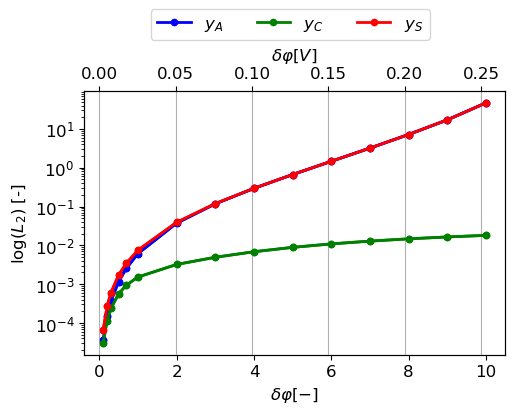

In [30]:
# Log-log plot of L2-error
fig_L2_NP, axs = plt.subplots(1, 1, figsize=(3.54*3/2, 3.54*10/9))
for property_, color_, label_ in zip([y_A_error_L2_NP, y_C_error_L2_NP, y_S_error_L2_NP], [color_y_A, color_y_C, color_y_S], ['$y_A$', '$y_C$', '$y_S$']):
    axs.semilogy(phi_left_vec_NP, property_, 'o-', label=label_, color=color_, linestyle=marker_default)
axs_twiny = axs.twiny()
for property_, color_ in zip([y_A_error_L2_NP, y_C_error_L2_NP, y_S_error_L2_NP], [color_y_A, color_y_C, color_y_S]):
    axs_twiny.semilogy(phi_left_vec_physical_NP, property_, 'o-', color=color_, linestyle=marker_default)
# axs.set_yscale('log')
axs.set_xlabel('$\delta \\varphi [-]$')
axs_twiny.set_xlabel('$\delta \\varphi [V]$')
axs.set_ylabel('log($L_2$) [-]')
axs.grid()

lgnd = fig_L2_NP.legend(bbox_to_anchor=(0.84,1.07), ncol=3)
fig_L2_NP.tight_layout()

fig_L2_NP.tight_layout()
fig_L2_NP.savefig(f'{savefig_directory}/ComparisonNernstPlanck/Convergence_L2error.pdf', bbox_inches='tight')
fig_L2_NP.show()

## Solvation

In [31]:
data_solvation_path = '../Data/Solvation.npz'
data_solvation = np.load(data_solvation_path)

x_solvation = data_solvation['x']
phi_solvation = data_solvation['phi']
p_solvation = data_solvation['p']
y_A_solvation = data_solvation['y_A']
y_C_solvation = data_solvation['y_C']
y_S_solvation = data_solvation['y_S']
Solvation_vec = data_solvation['Solvation_vec']

<>:5: SyntaxWarning: invalid escape sequence '\k'
<>:5: SyntaxWarning: invalid escape sequence '\k'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3900492680.py:5: SyntaxWarning: invalid escape sequence '\k'
  axs[0].plot(x_solvation[i], phi_solvation[i], linestyle=marker_phi, color=colors[i], label=f'$\kappa = {Solvation}$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3900492680.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


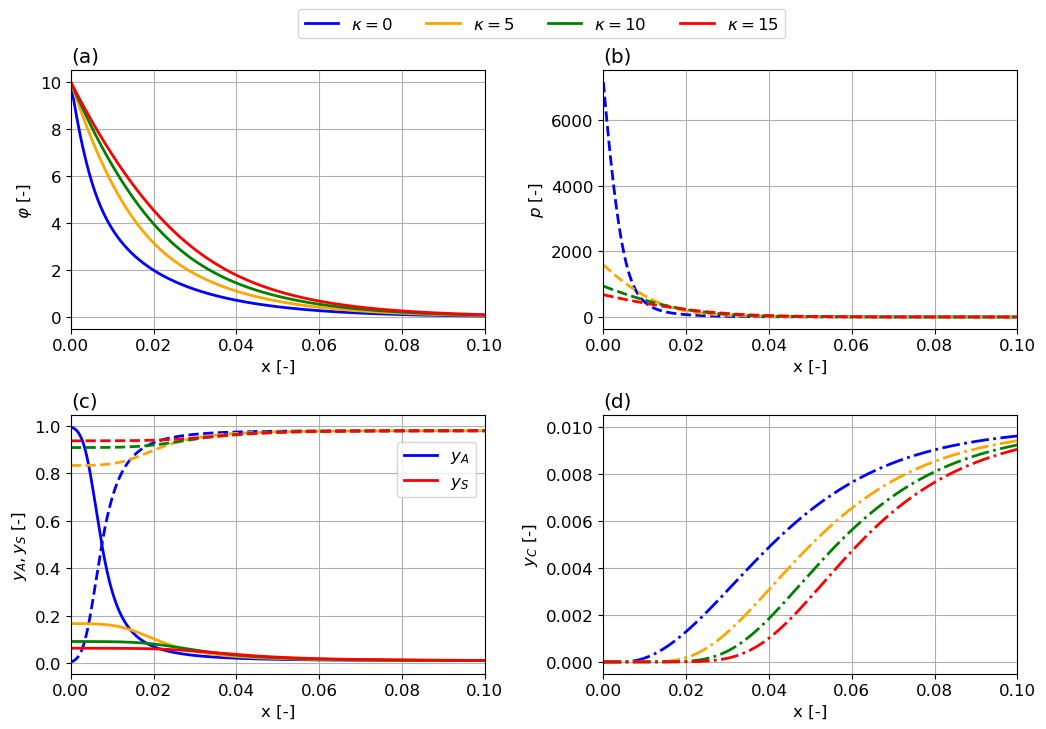

In [32]:
xlim_ = (0, 0.1)
fig, ax1, ax2, ax3, ax4 = get_gridspec_setup_ParamAna(xlim=xlim_)
axs = [ax1, ax2, ax3, ax4]
for i, Solvation in enumerate(Solvation_vec):
    axs[0].plot(x_solvation[i], phi_solvation[i], linestyle=marker_phi, color=colors[i], label=f'$\kappa = {Solvation}$')
    axs[1].plot(x_solvation[i], p_solvation[i], linestyle=marker_p, color=colors[i])
    axs[2].plot(x_solvation[i], y_A_solvation[i], linestyle=marker_y_A, color=colors[i])
    axs[2].plot(x_solvation[i], y_S_solvation[i], linestyle=marker_y_C, color=colors[i])
    axs[3].plot(x_solvation[i], y_C_solvation[i], linestyle=marker_y_S, color=colors[i])

dummy, = axs[2].plot([], [], linestyle=marker_default, color=color_y_A, label='$y_A$')
dummy, = axs[2].plot([], [], linestyle=marker_default, color=color_y_S, label='$y_S$')

[ax.set_xlabel('x [-]') for ax in axs]
axs[0].set_ylabel('$\\varphi$ [-]')
axs[1].set_ylabel('$p$ [-]')
axs[2].set_ylabel('$y_A, y_S$ [-]')
axs[3].set_ylabel('$y_C$ [-]')

# ToDo: Center lines for legend
order = [0, 1, 2, 3]
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], 
bbox_to_anchor=(0.755,1.04), ncol=4)
axs[2].legend(bbox_to_anchor=(1., .93))
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Solvation.pdf', bbox_inches='tight')
fig.show()

## Compressibility

In [33]:
df_compressibility_path = '../Data/Compressibility.npz'
df_compressibility = np.load(df_compressibility_path)

x_compressibility = df_compressibility['x']
phi_compressibility = df_compressibility['phi']
p_compressibility = df_compressibility['p']
y_A_compressibility = df_compressibility['y_A']
y_C_compressibility = df_compressibility['y_C']
y_S_compressibility = df_compressibility['y_S']
K_vec_compressibility = df_compressibility['K_vec']
n_compressibility = df_compressibility['n']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3736553541.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3736553541.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


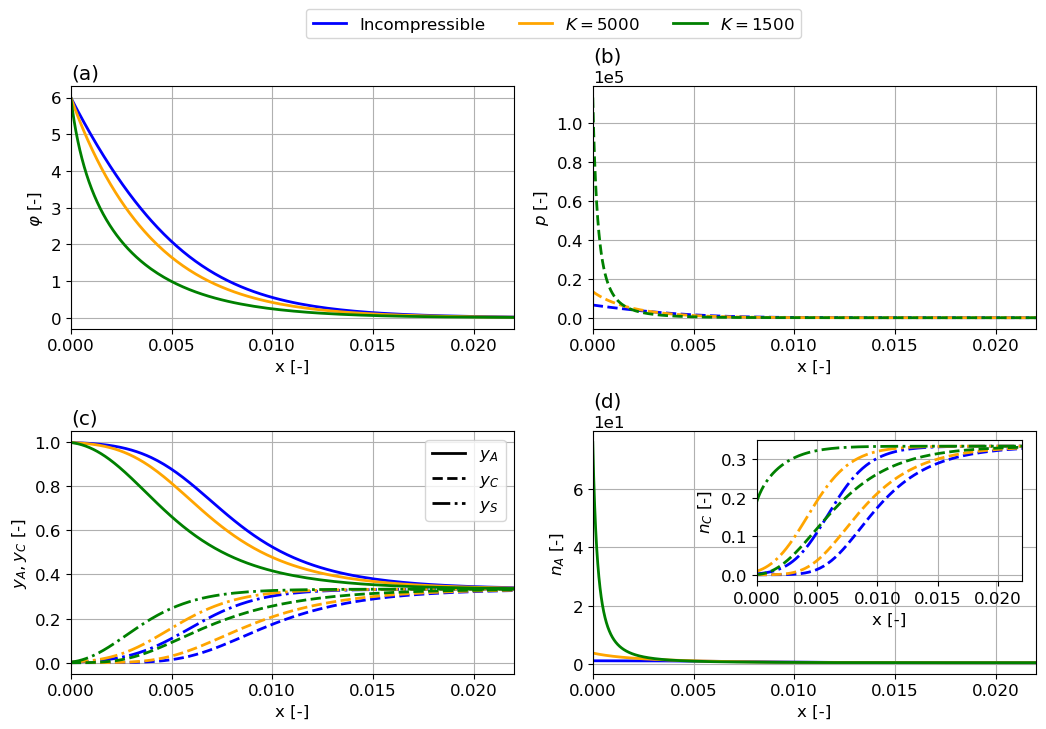

In [34]:
# xlim_ = (0, 0.025)
# Todo: Decide on xlim
xlim_ = (0, 0.022)
fig, ax1, ax2, ax3, ax4 = get_gridspec_setup_ParamAna(xlim=xlim_)
a = plt.axes([.72, .22, .25, .2])
a.set_xlim(xlim_)
axs = [ax1, ax2, ax3, ax4, a]
for i, K in enumerate(K_vec_compressibility[:-1]):
    if K == 'incompressible':
        axs[0].plot(x_compressibility[i], phi_compressibility[i], linestyle=marker_phi, color=colors[i], label='Incompressible')
    else:
        axs[0].plot(x_compressibility[i], phi_compressibility[i], linestyle=marker_phi, color=colors[i], label=f'$K = ${K}')
    axs[1].plot(x_compressibility[i], p_compressibility[i], linestyle=marker_p, color=colors[i])
    axs[2].plot(x_compressibility[i], y_A_compressibility[i], linestyle=marker_y_A, color=colors[i])
    axs[2].plot(x_compressibility[i], y_C_compressibility[i], linestyle=marker_y_C, color=colors[i])
    axs[2].plot(x_compressibility[i], y_S_compressibility[i], linestyle=marker_y_S, color=colors[i])
    axs[3].plot(x_compressibility[i], n_compressibility[i] * y_A_compressibility[i], linestyle=marker_y_A, color=colors[i])
    axs[4].plot(x_compressibility[i], n_compressibility[i] * y_C_compressibility[i], linestyle=marker_y_C, color=colors[i])
    axs[4].plot(x_compressibility[i], n_compressibility[i] * y_S_compressibility[i], linestyle=marker_y_S, color=colors[i])

dummy, = axs[2].plot([], [], linestyle=marker_y_A, color=color_default, label='$y_A$')
dummy, = axs[2].plot([], [], linestyle=marker_y_C, color=color_default, label='$y_C$')
dummy, = axs[2].plot([], [], linestyle=marker_y_S, color=color_default, label='$y_S$')

[ax.set_xlabel('x [-]') for ax in axs]
axs[0].set_ylabel('$\\varphi$ [-]')
axs[1].set_ylabel('$p$ [-]')
axs[2].set_ylabel('$y_A, y_C$ [-]')
axs[3].set_ylabel('$n_A$ [-]')
axs[4].set_ylabel('$n_C$ [-]')

# Change yformat for pressure and number densities
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# ToDo: Center lines for legend
order = [0, 1, 2]
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgnd = fig.legend([lines[i] for i in order], [labels[i] for i in order], 
bbox_to_anchor=(0.77,1.04), ncol=3)
axs[2].legend(bbox_to_anchor=(1., 1.))
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Compressibility.pdf', bbox_inches='tight')
fig.show()

## Double Layer Capacity

### Molarity

In [35]:
data_Molarity_path = '../Data/DoubleLayerCapacity/Molarity.npz'
data_Molarity = np.load(data_Molarity_path)

Q_DL_Molarity = data_Molarity['Q_DL_dimless_']
Phi_Pot_DL_Molarity = data_Molarity['Phi_Pot_Diff_dimless']
C_DL_DL_Molarity = data_Molarity['C_DL_dimless']
Molarity_DL_Molarity = data_Molarity['Molarity']

data_PB_Molarity_path = '../Data/DoubleLayerCapacity/PB.npz'
data_PB_Molarity = np.load(data_PB_Molarity_path)

Q_DL_PB_Molarity = data_PB_Molarity['Q_DL_dimless_PB_']
Phi_Pot_DL_PB_Molarity = data_PB_Molarity['Phi_Pot_Diff_dimless_PB']
Phi_Pot_center_array_DL_PB_Molarity = data_PB_Molarity['Phi_pot_center_array_dimless_PB']
C_DL_DL_PB_Molarity = data_PB_Molarity['C_DL_dimless_PB']
Molarity_DL_PB_Molarity = data_PB_Molarity['Molarity']

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2970508453.py:1: SyntaxWarning: invalid escape sequence '\d'
  fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2970508453.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


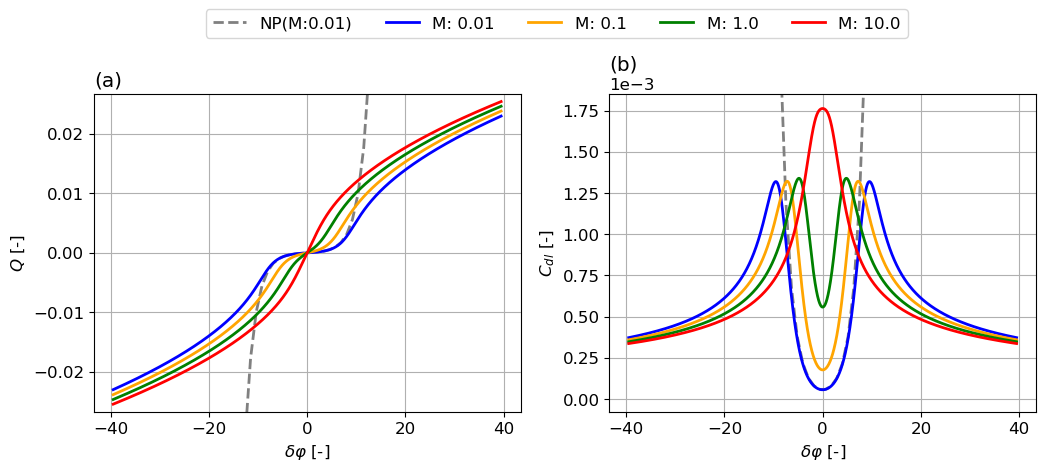

In [36]:
fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
ax1.plot(Phi_Pot_DL_PB_Molarity, Q_DL_PB_Molarity, linestyle='--', color='gray', label=f'NP(M:{Molarity_DL_Molarity[0]})')
for i, q_dl in enumerate(Q_DL_Molarity):
    ax1.plot(Phi_Pot_DL_Molarity, q_dl, linestyle=marker_default, color=colors[i], label=f'M: {Molarity_DL_Molarity[i]}')
ax1.set_ylim(np.min(Q_DL_Molarity)*upper_limit_phi_ratio, np.max(Q_DL_Molarity)*upper_limit_phi_ratio)
ax1.set_ylabel('$Q$ [-]')

ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax2.plot(Phi_Pot_center_array_DL_PB_Molarity, C_DL_DL_PB_Molarity, linestyle='--', color='gray')
for i, c_dl in enumerate(C_DL_DL_Molarity):
    ax2.plot(Phi_Pot_DL_Molarity, c_dl, linestyle=marker_default, color=colors[i])
ax2.set_ylim(-phi_extra_added_fraction/2*(np.max(C_DL_DL_Molarity) - np.min(C_DL_DL_Molarity)), np.max(C_DL_DL_Molarity)*upper_limit_phi_ratio)
ax2.set_ylabel('$C_{dl}$ [-]')

lgnd = fig.legend(bbox_to_anchor=(0.87,1.08), ncol=5)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Charge_Capacity_Molarity.pdf', bbox_inches='tight')
fig.show()

### $\lambda^2$

In [37]:
data_Lambda2_path = '../Data/DoubleLayerCapacity/Lambda.npz'
data_Lambda2 = np.load(data_Lambda2_path)

Q_DL_Lambda2 = data_Lambda2['Q_DL_dimless_']
Phi_Pot_DL_Lambda2 = data_Lambda2['Phi_Pot_Diff_dimless']
C_DL_DL_Lambda2 = data_Lambda2['C_DL_dimless']
Lambda2_DL_Lambda2 = data_Lambda2['Lambda2_vec']

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1627866038.py:1: SyntaxWarning: invalid escape sequence '\d'
  fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1627866038.py:3: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(Phi_Pot_DL_Lambda2, q_dl, linestyle=marker_default, color=colors[i], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]:.1e}')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1627866038.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


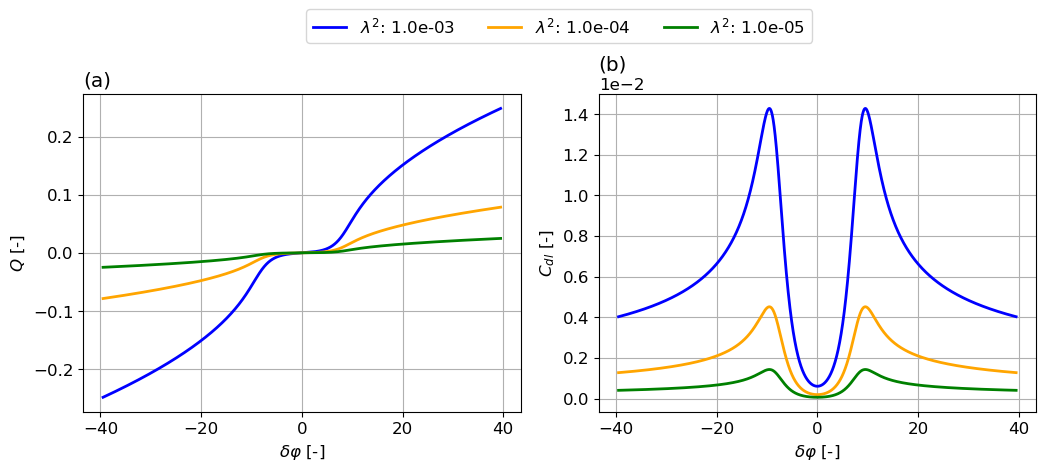

In [38]:
fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
for i, q_dl in enumerate(Q_DL_Lambda2):
    ax1.plot(Phi_Pot_DL_Lambda2, q_dl, linestyle=marker_default, color=colors[i], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]:.1e}')
ax1.set_ylabel('$Q$ [-]')

for i, c_dl in enumerate(C_DL_DL_Lambda2):
    ax2.plot(Phi_Pot_DL_Lambda2, c_dl, linestyle=marker_default, color=colors[i])
ax2.set_ylabel('$C_{dl}$ [-]')
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

lgnd = fig.legend(bbox_to_anchor=(0.78,1.08), ncol=5)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Charge_Capacity_Lambda2.pdf', bbox_inches='tight')
fig.show()

### Compressibility

In [39]:
data_Compressibility_path = '../Data/DoubleLayerCapacity/DLKap_Compressibility.npz'
data_Compressibility = np.load(data_Compressibility_path)

Q_DL_Compressibility = data_Compressibility['Q_DL_dimless_']
Phi_Pot_DL_Compressibility = data_Compressibility['Phi_Pot_Diff_dimless']
C_DL_DL_Compressibility = data_Compressibility['C_DL_dimless']
Compressibility_DL_Compressibility = data_Compressibility['K_vec']

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2442027057.py:1: SyntaxWarning: invalid escape sequence '\d'
  fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/2442027057.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


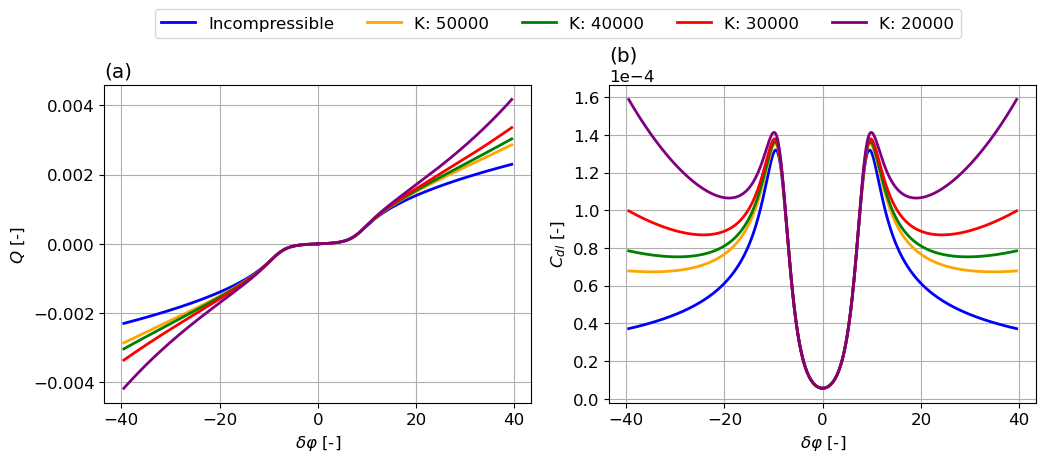

In [40]:
fig, ax1, ax2 = get_gridspec_setup_2rows(figsize=(3.54*3, 3.54*5/4), xlabel='$\delta \\varphi$ [-]')
for i, q_dl in enumerate(Q_DL_Compressibility):
    if i == 0:
        ax1.plot(Phi_Pot_DL_Compressibility, q_dl, linestyle=marker_default, color=colors[i], label=f'Incompressible')
    else:
        ax1.plot(Phi_Pot_DL_Compressibility, q_dl, linestyle=marker_default, color=colors[i], label=f'K: {Compressibility_DL_Compressibility[i]}')
ax1.set_ylabel('$Q$ [-]')


ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
for i, c_dl in enumerate(C_DL_DL_Compressibility):
    ax2.plot(Phi_Pot_DL_Compressibility, c_dl, linestyle=marker_default, color=colors[i])
ax2.set_ylabel('$C_{dl}$ [-]')

lgnd = fig.legend(bbox_to_anchor=(0.92,1.06), ncol=5)
fig.tight_layout()
fig.savefig(f'{savefig_directory}/Charge_Capacity_Compressibility.pdf', bbox_inches='tight')
fig.show()

# Many Constituent Mixture

In [41]:
# load the data
many_const_path_A = '../Data/NConstituentsMixture/Mixture_A.npz'
many_const_path_B = '../Data/NConstituentsMixture/Mixture_B.npz'
many_const_path_C = '../Data/NConstituentsMixture/Mixture_C.npz'
many_const_path_D = '../Data/NConstituentsMixture/Mixture_D.npz'

df_many_const_A =  np.load(many_const_path_A)
df_many_const_B =  np.load(many_const_path_B)
df_many_const_C =  np.load(many_const_path_C)
df_many_const_D =  np.load(many_const_path_D)

# extract the data
x_many_const, phi_many_const, p_many_const, y_many_const, z_many_const = [], [], [], [], []
for data in [df_many_const_A, df_many_const_B, df_many_const_C, df_many_const_D]:
    x_many_const.append(data['x'])
    phi_many_const.append(data['phi'])
    p_many_const.append(data['p'])
    y_many_const.append(data['y_alpha'])
    z_many_const.append(data['z_alpha'])

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/3682753552.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


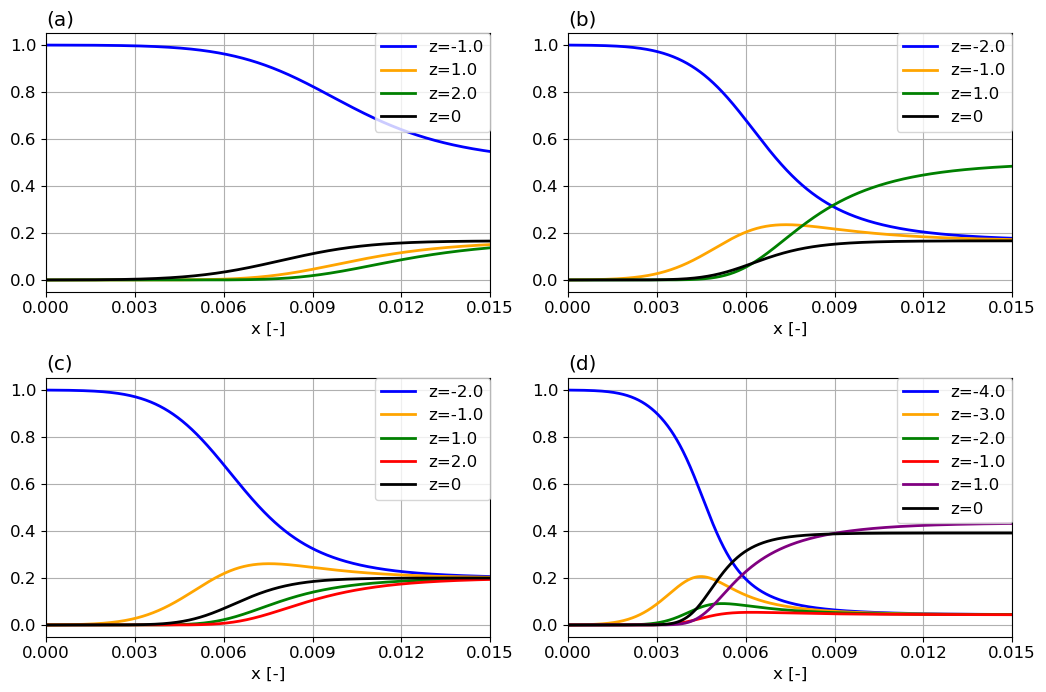

In [42]:
xlim_ = (0, 0.015)
fig, ax1, ax2, ax3, ax4 = get_gridspec_setup_ParamAna(xlim=xlim_)
axs = [ax1, ax2, ax3, ax4]

for mixture_index in range(4):
    for species in range(len(z_many_const[mixture_index])):
        axs[mixture_index].plot(x_many_const[mixture_index], y_many_const[mixture_index][species], linestyle=marker_default, color=colors[species], label=f'z={z_many_const[mixture_index][species]}')
    y_S_ = 1 - np.sum(y_many_const[mixture_index], axis=0)
    axs[mixture_index].plot(x_many_const[mixture_index], y_S_, linestyle=marker_default, color=colors[-1], label=f'z=0')
    axs[mixture_index].legend(loc='upper right', borderaxespad=0.)
    axs[mixture_index].set_xticks([0, 0.003, 0.006, 0.009, 0.012, 0.015])

fig.tight_layout()
fig.savefig(f'{savefig_directory}/ManyConstituentMixture.pdf', bbox_inches='tight')
fig.show()

# Electrolytic Diode

### Setup sketch

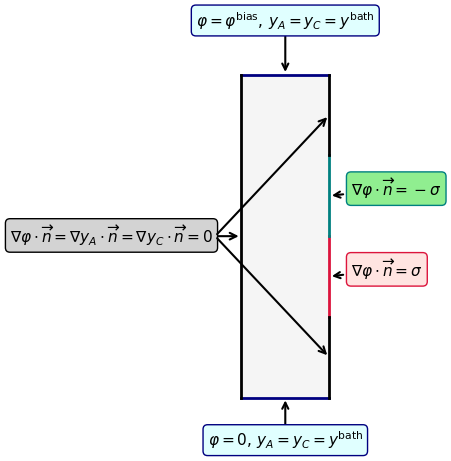

In [43]:
# Created with: ChatGPT. https://chatgpt.com

# Define the domain limits
x_min, x_max = 0, 2  # 2 units in x-direction
y_min, y_max = 0, 10  # 10 units in y-direction

# Create the figure and axis
fig, ax = plt.subplots()

# Add a light background color for the domain
ax.fill_between([x_min, x_max], y_min, y_max, color='whitesmoke')

# Colorize the bottom and top boundaries
ax.plot([x_min, x_max], [y_min, y_min], color='navy', linewidth=2)  # Bottom boundary
ax.plot([x_min, x_max], [y_max, y_max], color='navy', linewidth=2)  # Top boundary

# Colorize the right boundary with Neumann conditions
ax.plot([x_max, x_max], [2.5, 5], color='crimson', linewidth=2)    # Right boundary: 2.5 <= y <= 5 (crimson)
ax.plot([x_max, x_max], [5, 7.5], color='teal', linewidth=2)       # Right boundary: 5 < y <= 7.5 (teal)

# Colorize the left boundary and unspecified parts of the right boundary with black for homogeneous Neumann boundary
ax.plot([x_min, x_min], [y_min, y_max], color='black', linestyle='-', linewidth=2)  # Left boundary
ax.plot([x_max, x_max], [y_min, 2.5], color='black', linestyle='-', linewidth=2)    # Right boundary: y < 2.5
ax.plot([x_max, x_max], [7.5, y_max], color='black', linestyle='-', linewidth=2)    # Right boundary: y > 7.5

# Annotate the bottom boundary
ax.annotate(r"$\varphi = 0, \, y_A = y_C = y^{\mathrm{bath}}$", xy=((x_min + x_max) / 2, y_min), 
            xytext=((x_min + x_max) / 2, y_min - 1.5), ha='center', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='navy', facecolor='lightcyan'),
            arrowprops=dict(facecolor='navy', arrowstyle='->', lw=1.5, shrinkA=0))

# Annotate the top boundary
ax.annotate(r"$\varphi = \varphi^{\mathrm{bias}}, \, y_A = y_C = y^{\mathrm{bath}}$", xy=((x_min + x_max) / 2, y_max), 
            xytext=((x_min + x_max) / 2, y_max + 1.5), ha='center', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='navy', facecolor='lightcyan'),
            arrowprops=dict(facecolor='navy', arrowstyle='->', lw=1.5, shrinkA=0))

# Annotate the right boundary for 2.5 <= y <= 5
ax.annotate(r"$\nabla \varphi \cdot \overrightarrow{n} = \sigma$", xy=(x_max, 3.75), 
            xytext=(x_max + 0.5, 3.75), ha='left', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='mistyrose'),
            arrowprops=dict(facecolor='crimson', arrowstyle='->', lw=1.5))

# Annotate the right boundary for 5 < y <= 7.5
ax.annotate(r"$\nabla \varphi \cdot \overrightarrow{n} = -\sigma$", xy=(x_max, 6.25), 
            xytext=(x_max + 0.5, 6.25), ha='left', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='teal', facecolor='lightgreen'),
            arrowprops=dict(facecolor='teal', arrowstyle='->', lw=1.5))

# Adjust the y-position of the homogeneous Neumann boundary conditions box
hnb_text = ax.annotate(r"$\nabla \varphi \cdot \overrightarrow{n} = \nabla y_A \cdot \overrightarrow{n} = \nabla y_C \cdot \overrightarrow{n}= 0$", xy=(x_min, (y_min + y_max) / 2), xytext=(x_min - 0.6 - 0.05, (y_min + y_max) / 2 - 0.5 +0.3), ha='right', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgrey'))


# Indicate homogeneous Neumann conditions are valid on the right side
ax.annotate("", xy=(x_max, 1.25), xytext=(x_min - 0.6, (y_min + y_max) / 2), 
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5))
ax.annotate("", xy=(x_max, 8.75), xytext=(x_min - 0.6, (y_min + y_max) / 2), 
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5))

# Indicate horizontal arrow from the left to the middle of the annotation
ax.annotate("", xy=(x_min, (y_min + y_max) / 2), xytext=(x_min - 0.6, (y_min + y_max) / 2), 
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5))

# Remove the axis lines and ticks
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Save the figure as 'EDiodeDomain.svg'
plt.savefig(f'{savefig_directory}/ElectrolyticDiode/ElectrolyticDiode_Domain.pdf')

plt.show()


### Results

In [44]:
# load the data
Diode_path_ForwardBias = '../Data/ElectrolyticDiode/ForwardBias.npz'
Diode_path_NoBias = '../Data/ElectrolyticDiode/NoBias.npz'
Diode_path_BackwardBias = '../Data/ElectrolyticDiode/BackwardBias.npz'

df_ForwardBias =  np.load(Diode_path_ForwardBias)
df_NoBias =  np.load(Diode_path_NoBias)
df_BackwardBias =  np.load(Diode_path_BackwardBias)

# extract the data
x_Diode, y_Diode, phi_Diode, p_Diode, y_A_Diode, y_C_Diode, y_S_Diode = [], [], [], [], [], [], []
for data in [df_ForwardBias, df_NoBias, df_BackwardBias]:
    x_Diode.append(data['x'])
    y_Diode.append(data['y'])
    phi_Diode.append(data['phi'])
    p_Diode.append(data['p'])
    y_A_Diode.append(data['y_A'])
    y_C_Diode.append(data['y_C'])
    y_S_Diode.append(data['y_S'])

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/4153836204.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


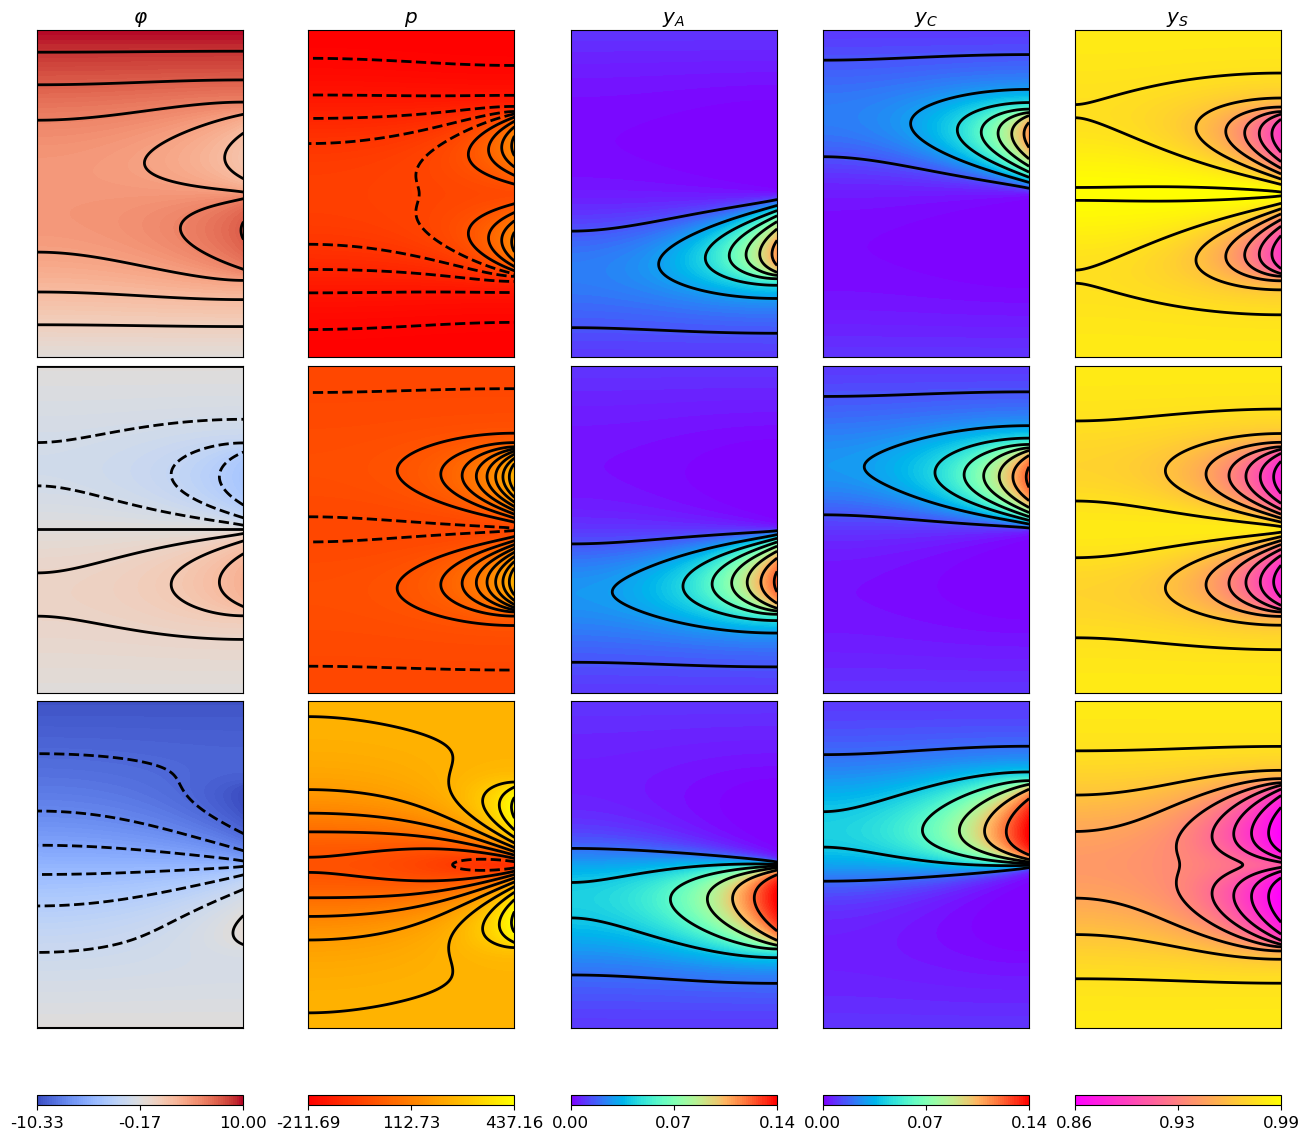

In [45]:
fig, axsForward, axsNo, axsBackward = get_gridspec_setup_Diode(figsize=(3.54*11, 3.54*16), subtitlte=False, layout='constrained')
colorthemes = ['coolwarm', 'autumn', 'rainbow', 'rainbow', 'spring']
levels_colorbar = 100
levels_contour = 8#20
vmap_concentrations = np.linspace(np.min([np.min(y_A_Diode), np.min(y_C_Diode)]), np.max([np.max(y_A_Diode), np.max(y_C_Diode)]), levels_colorbar)
vmap_solvent = np.linspace(np.min(y_S_Diode), np.max(y_S_Diode), levels_colorbar)
vmap_potential = np.linspace(np.min(phi_Diode), np.max(phi_Diode), levels_colorbar)
vmap_pressure = np.linspace(np.min(p_Diode), np.max(p_Diode), levels_colorbar)
vmaps = [vmap_potential, vmap_pressure, vmap_concentrations, vmap_concentrations, vmap_solvent]
properties_Diode = [phi_Diode, p_Diode, y_A_Diode, y_C_Diode, y_S_Diode]
properties_Diode_counter = [0, 1, 2, 3, 4]
properties_Diode_title = ['$\\varphi$', '$p$', '$y_A$', '$y_C$', '$y_S$']

axs = [axsForward, axsNo, axsBackward]
for bias_, ax in enumerate(axs): # iterate over biases
    for property, property_counter_, colortheme_, vmap_ in zip(properties_Diode, properties_Diode_counter, colorthemes, vmaps): # iterate over properties
        c = ax[property_counter_].tricontourf(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=vmap_, cmap=colortheme_)
        if ax in axsBackward:
            cbar = fig.colorbar(c, ax=ax[property_counter_], orientation='horizontal', pad=0.2, fraction=0.05)
            labels_cbar = np.linspace(np.min(vmap_), np.max(vmap_), 3)
            cbar.set_ticks(labels_cbar)
            cbar.set_ticklabels([f'{tick:.2f}' for tick in labels_cbar], rotation=0)
        ax[property_counter_].tricontour(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=levels_contour, colors='k')
        # suppress xticks and yticks
        ax[property_counter_].set_xticks([])
        ax[property_counter_].set_yticks([])

[axsForward[property_counter_].set_title(f'{properties_Diode_title[property_counter_]}') for property_counter_ in properties_Diode_counter] # add property at first row

for ax in axs:
    for prop in range(5):
        ax[prop].grid()

# fig.tight_layout()
fig.savefig(f'{savefig_directory}/ElectrolyticDiode/ElectrolyticDiode_Results_reduced.pdf', bbox_inches='tight')

fig.show()

<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/255106890.py:21: SyntaxWarning: invalid escape sequence '\i'
  ax[property_counter_].set_title(f'{properties_Diode_title[property_counter_]} $\in ({round(np.min(property[bias_]),2)},{round(np.max(property[bias_]), 2)})$[-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/255106890.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


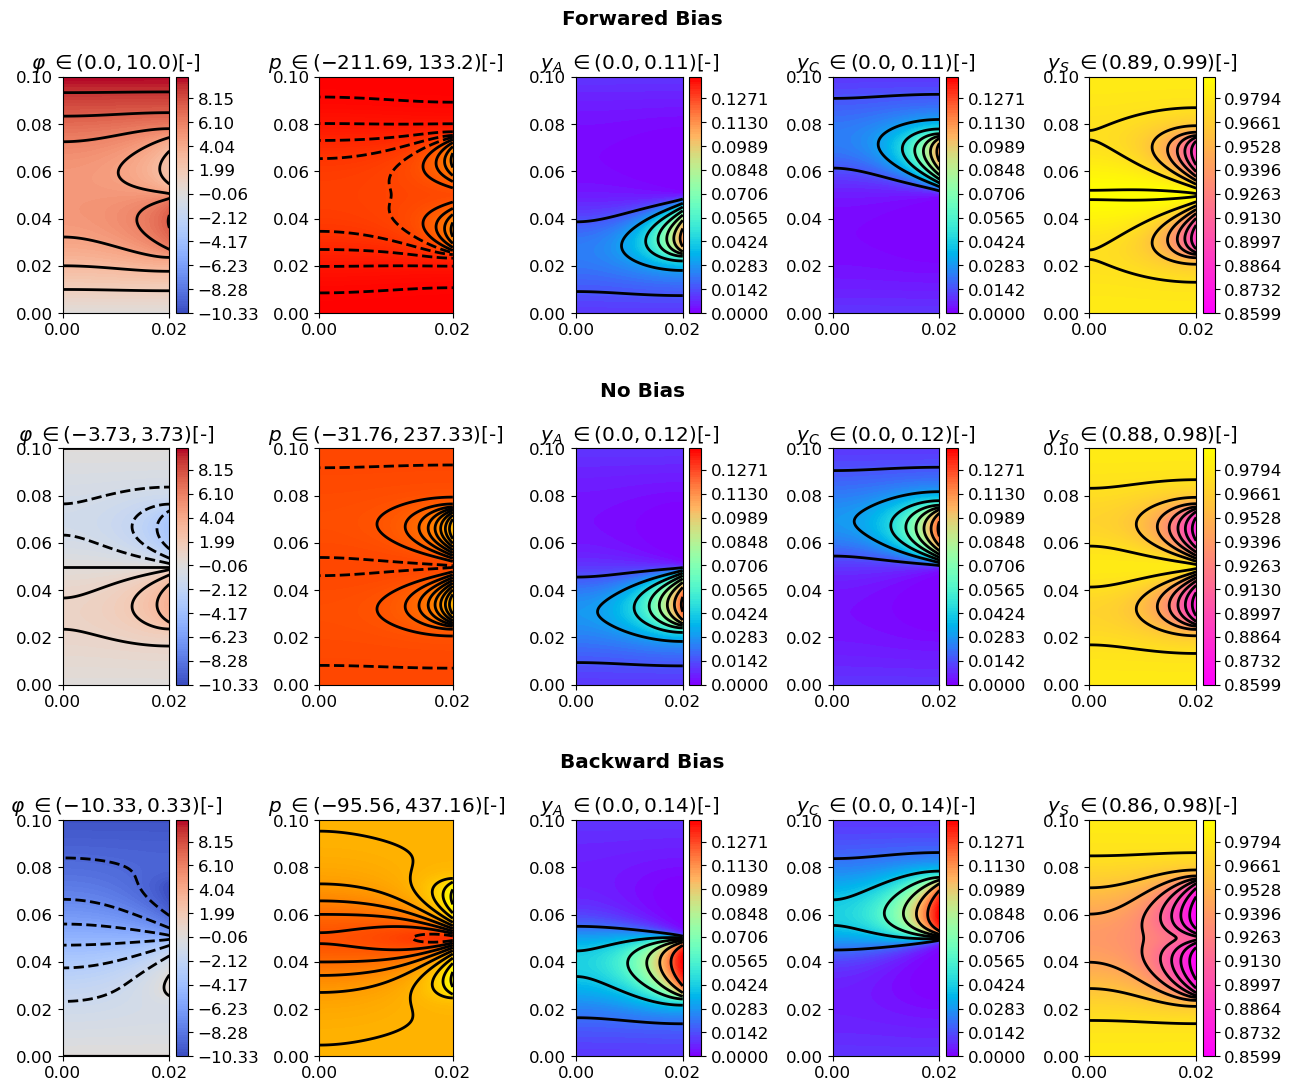

In [46]:
fig, axsForward, axsNo, axsBackward = get_gridspec_setup_Diode(figsize=(3.54*11, 3.54*16))
colorthemes = ['coolwarm', 'autumn', 'rainbow', 'rainbow', 'spring']
levels_colorbar = 100
levels_contour = 8#20
vmap_concentrations = np.linspace(np.min([np.min(y_A_Diode), np.min(y_C_Diode)]), np.max([np.max(y_A_Diode), np.max(y_C_Diode)]), levels_colorbar)
vmap_solvent = np.linspace(np.min(y_S_Diode), np.max(y_S_Diode), levels_colorbar)
vmap_potential = np.linspace(np.min(phi_Diode), np.max(phi_Diode), levels_colorbar)
vmap_pressure = np.linspace(np.min(p_Diode), np.max(p_Diode), levels_colorbar)
vmaps = [vmap_potential, vmap_pressure, vmap_concentrations, vmap_concentrations, vmap_solvent]
properties_Diode = [phi_Diode, p_Diode, y_A_Diode, y_C_Diode, y_S_Diode]
properties_Diode_counter = [0, 1, 2, 3, 4]
properties_Diode_title = ['$\\varphi$', '$p$', '$y_A$', '$y_C$', '$y_S$']

axs = [axsForward, axsNo, axsBackward]
for bias_, ax in enumerate(axs): # iterate over biases
    for property, property_counter_, colortheme_, vmap_ in zip(properties_Diode, properties_Diode_counter, colorthemes, vmaps): # iterate over properties
        c = ax[property_counter_].tricontourf(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=vmap_, cmap=colortheme_)
        if property_counter_ in [0, 2, 3, 4]: # skip y_A to combine the colorbar with y_C
            cbar = fig.colorbar(c, ax=ax[property_counter_])
        ax[property_counter_].tricontour(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=levels_contour, colors='k')
        ax[property_counter_].set_title(f'{properties_Diode_title[property_counter_]} $\in ({round(np.min(property[bias_]),2)},{round(np.max(property[bias_]), 2)})$[-]')

for ax in axs:
    for prop in range(5):
        ax[prop].grid()

fig.tight_layout()
fig.savefig(f'{savefig_directory}/ElectrolyticDiode/ElectrolyticDiode_Results.pdf', bbox_inches='tight')
fig.show()

<>:19: SyntaxWarning: invalid escape sequence '\i'
<>:19: SyntaxWarning: invalid escape sequence '\i'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1276746905.py:19: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title(f'{property_title} $\in ({round(np.min(property[bias_]),2)},{round(np.max(property[bias_]), 2)})$[-]')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1276746905.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1276746905.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1276746905.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_29139/1276746905.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus ca

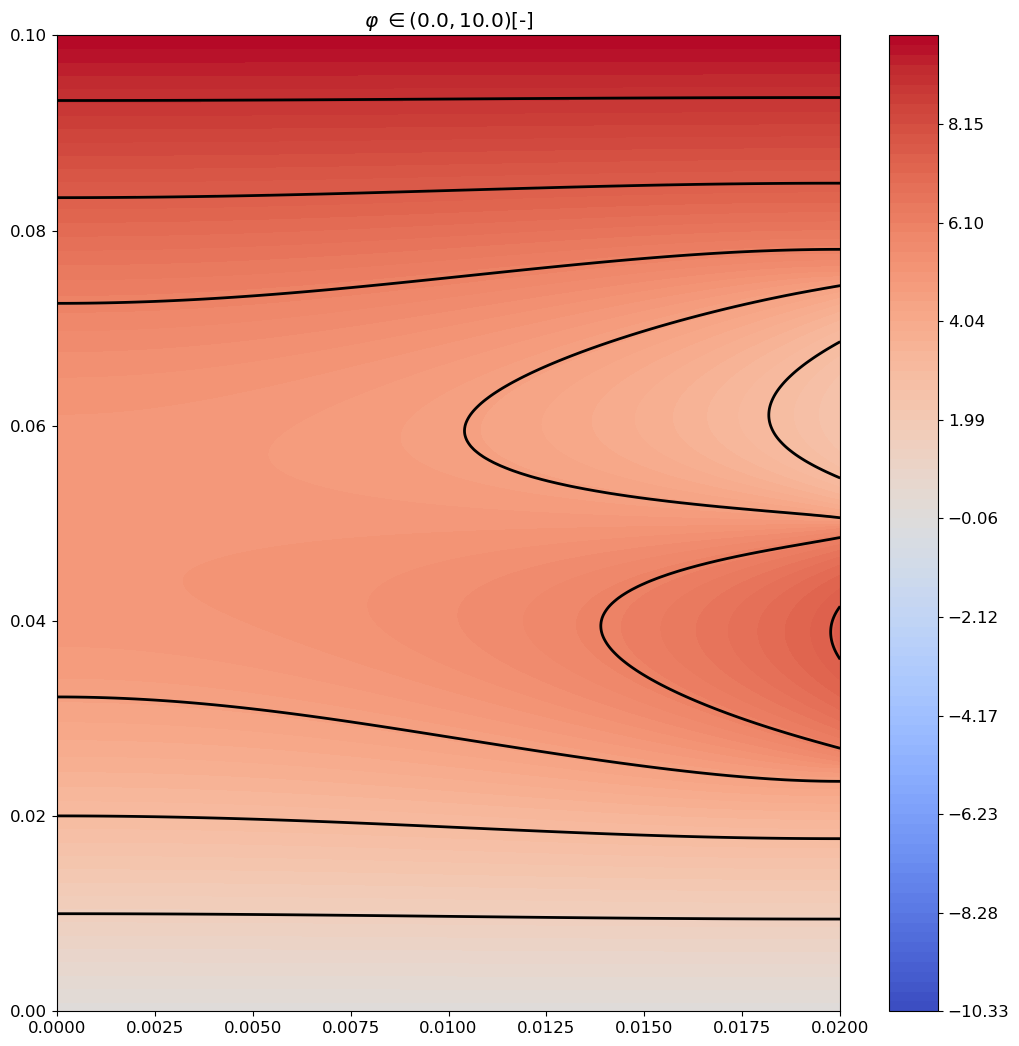

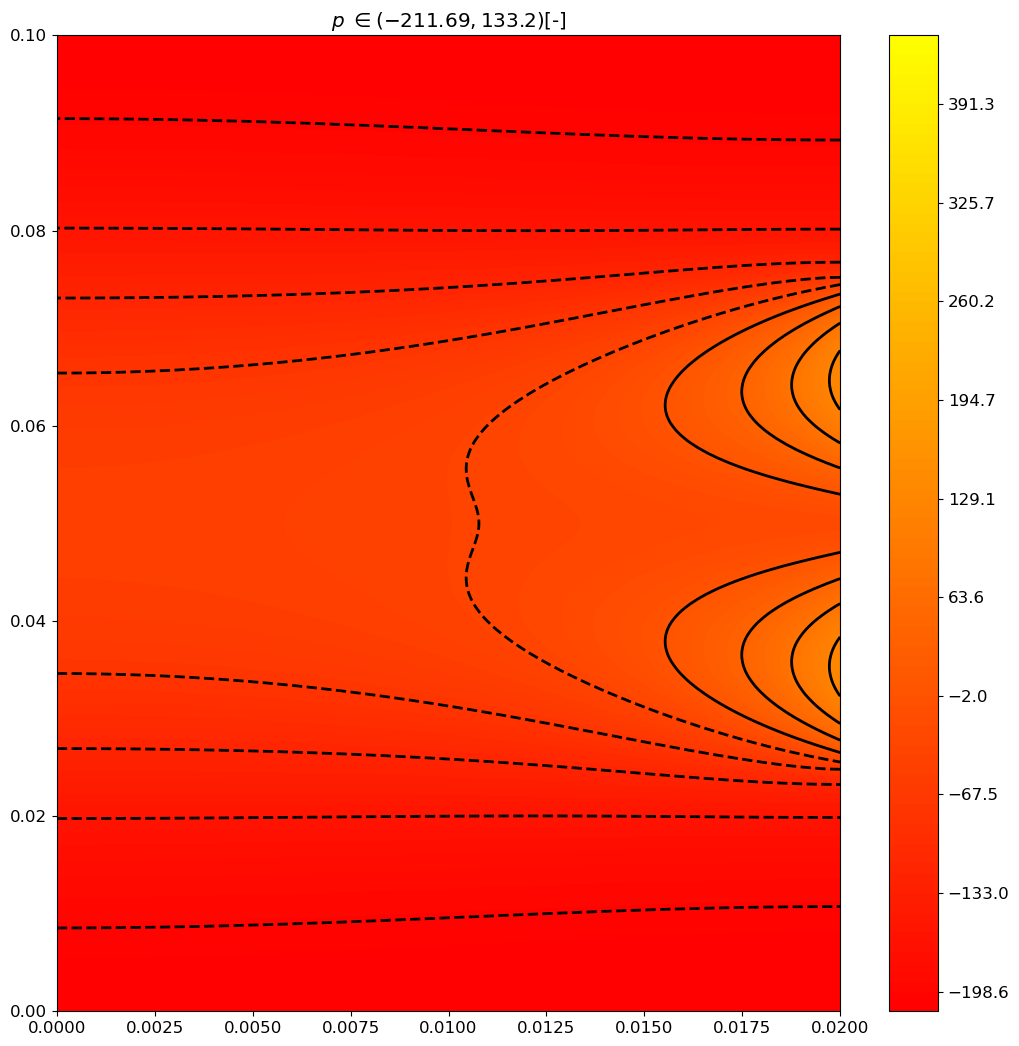

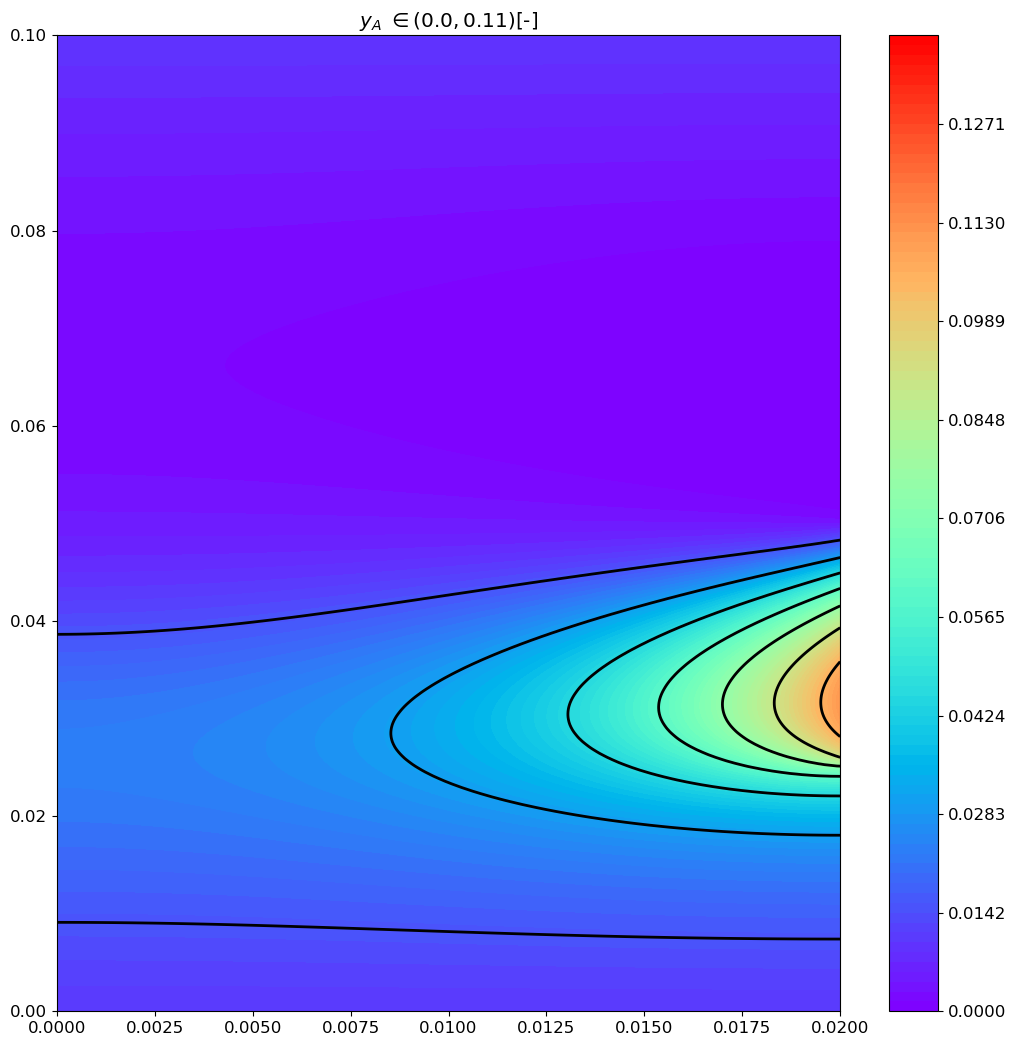

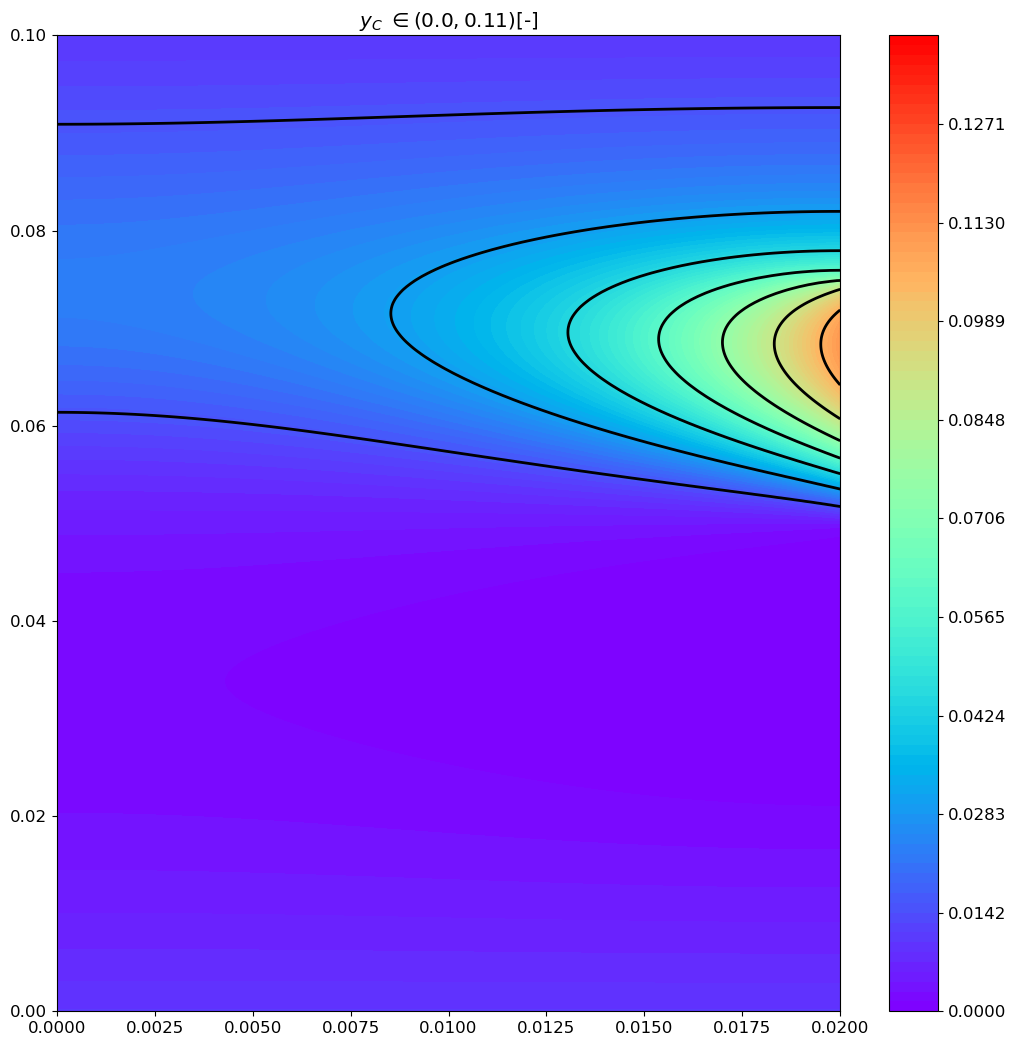

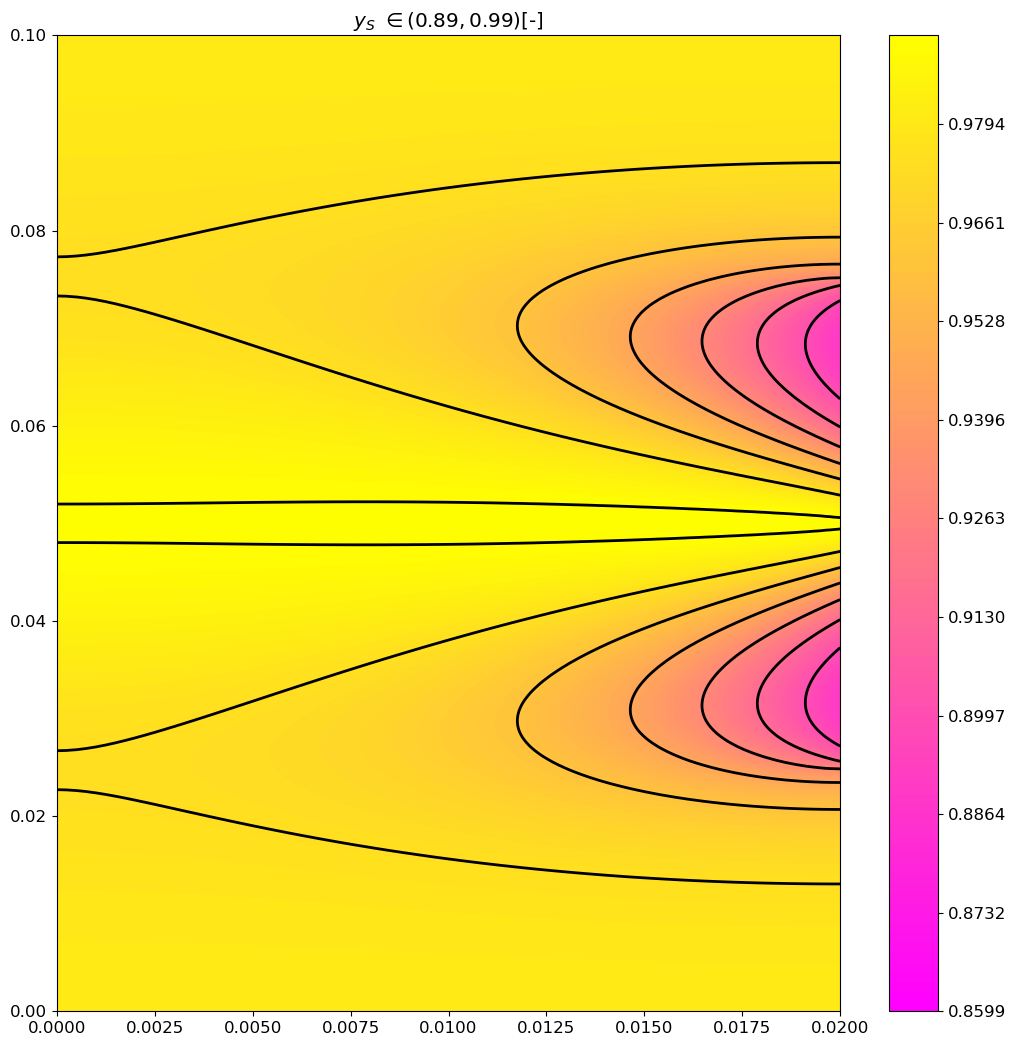

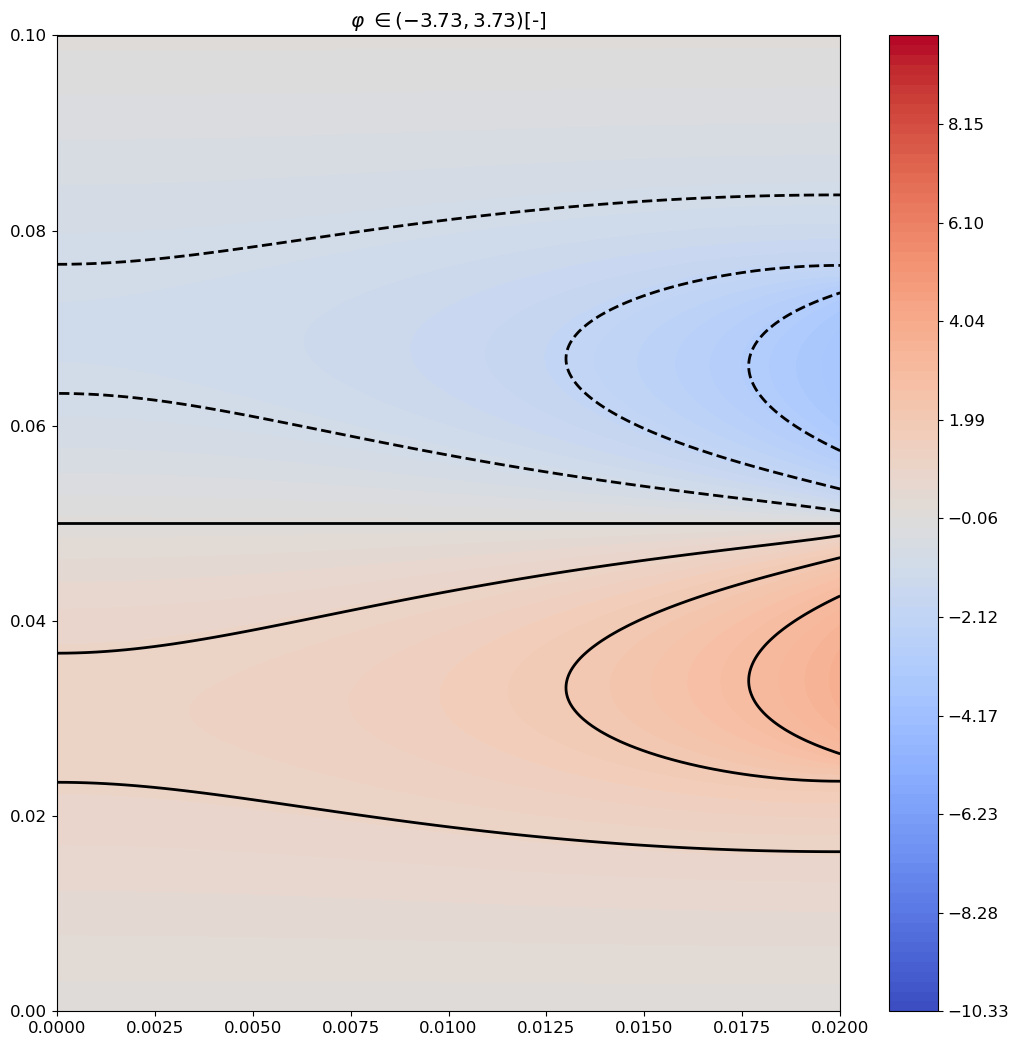

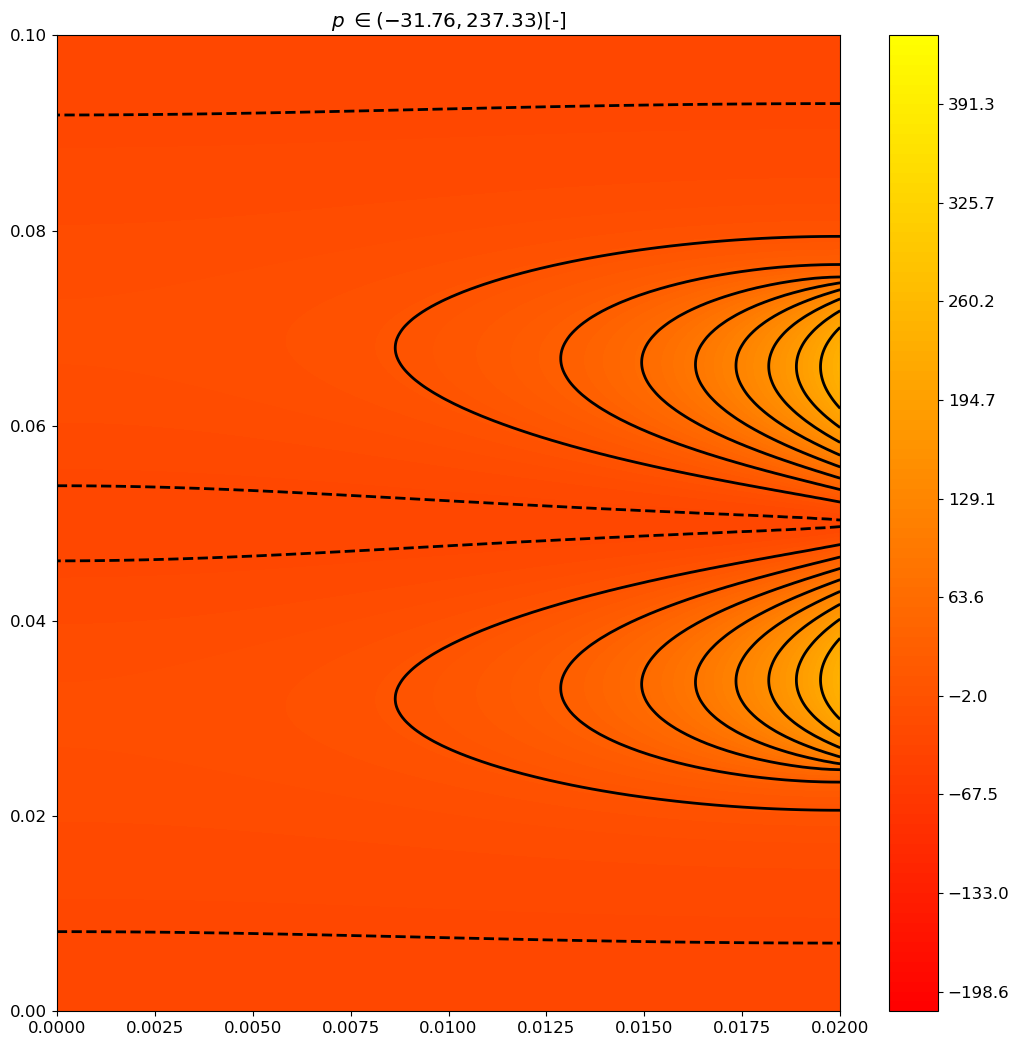

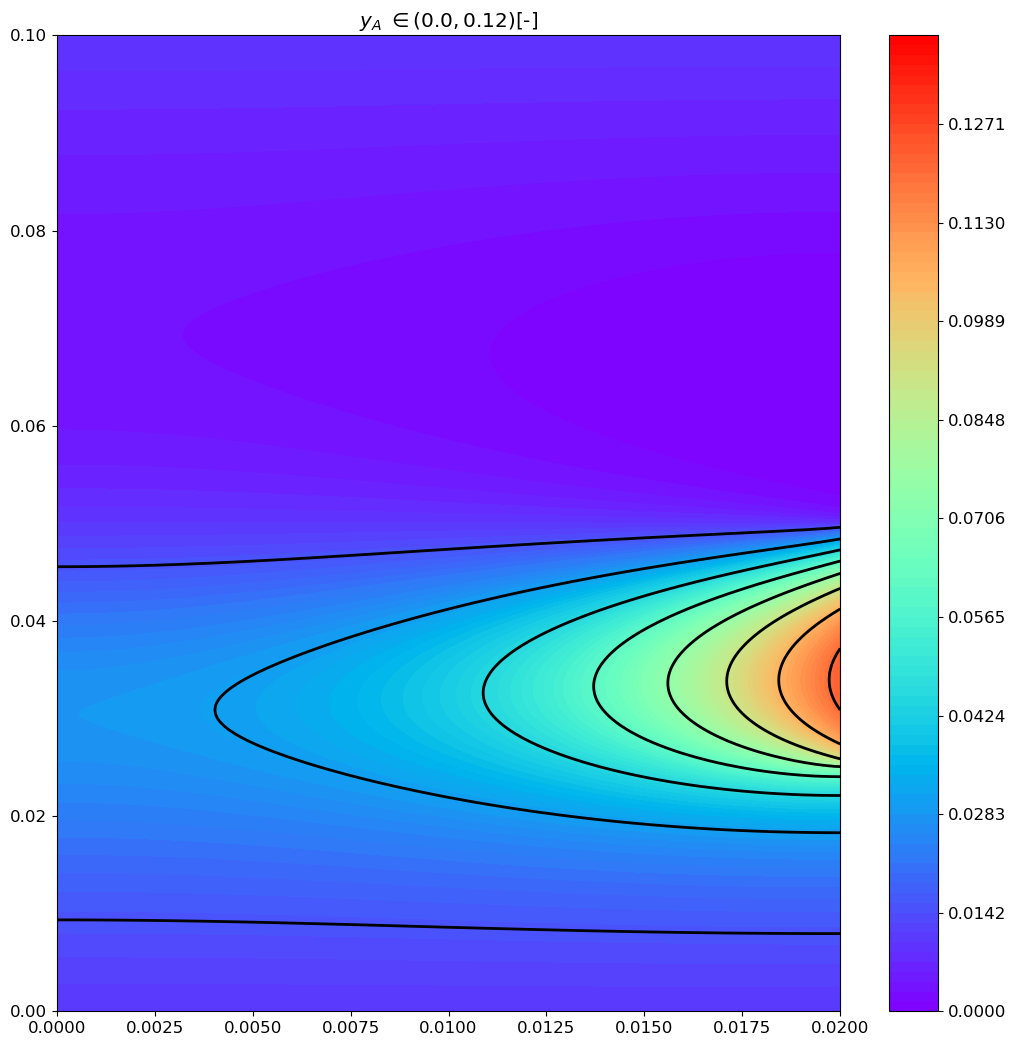

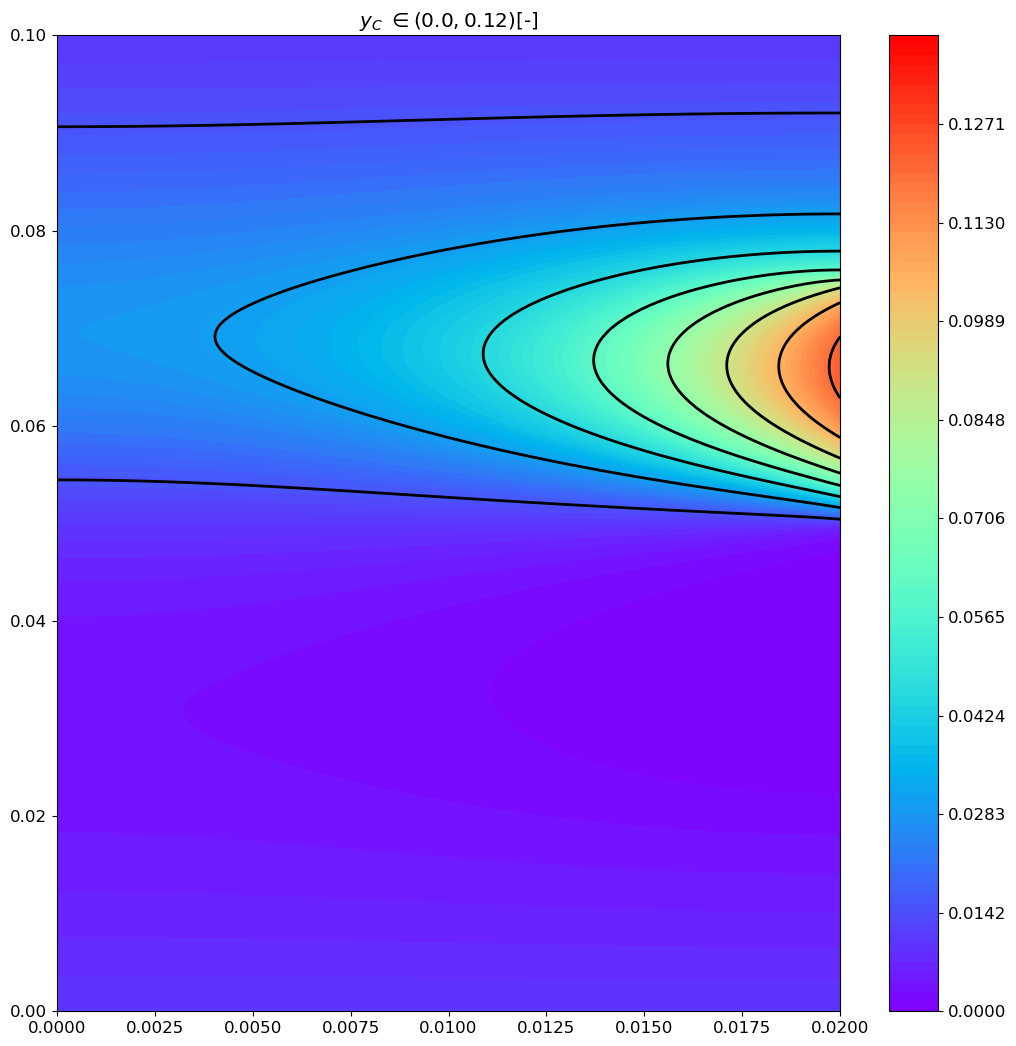

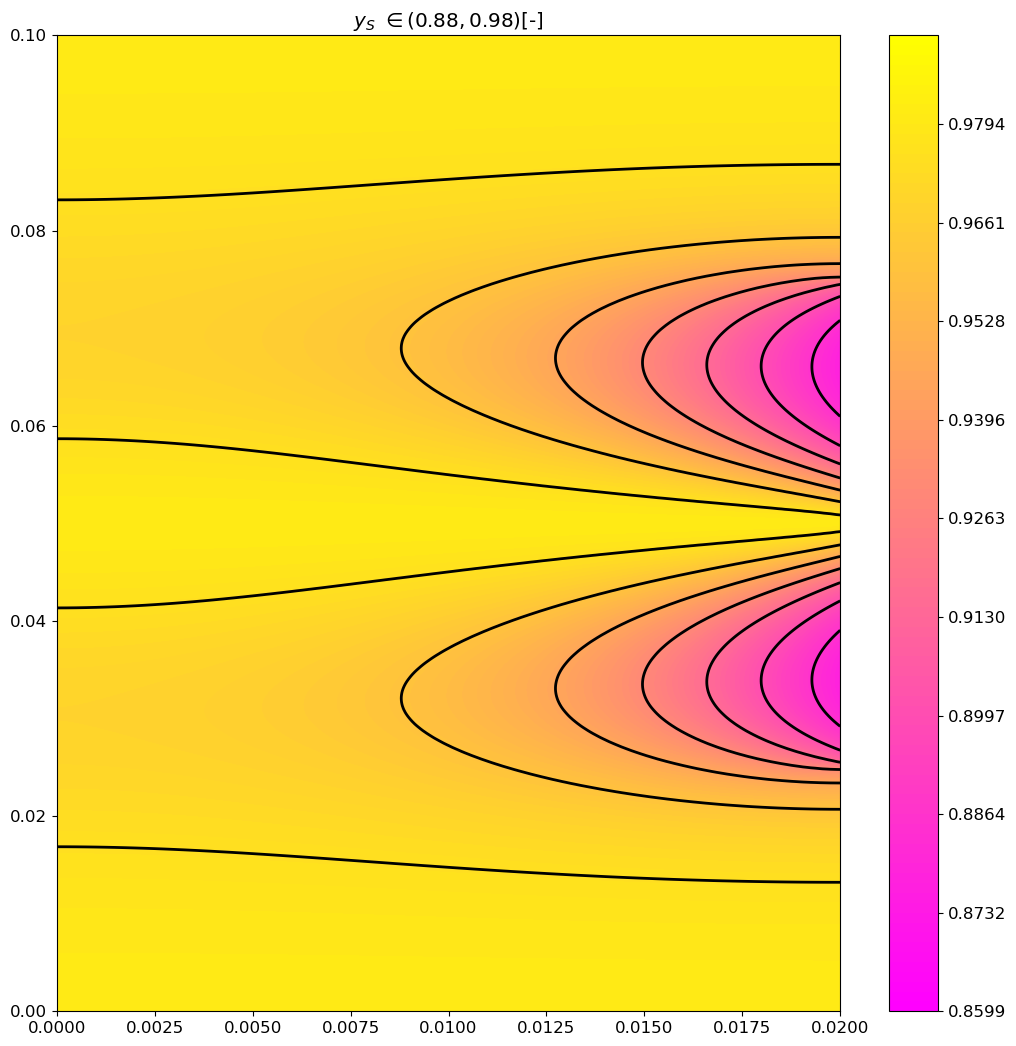

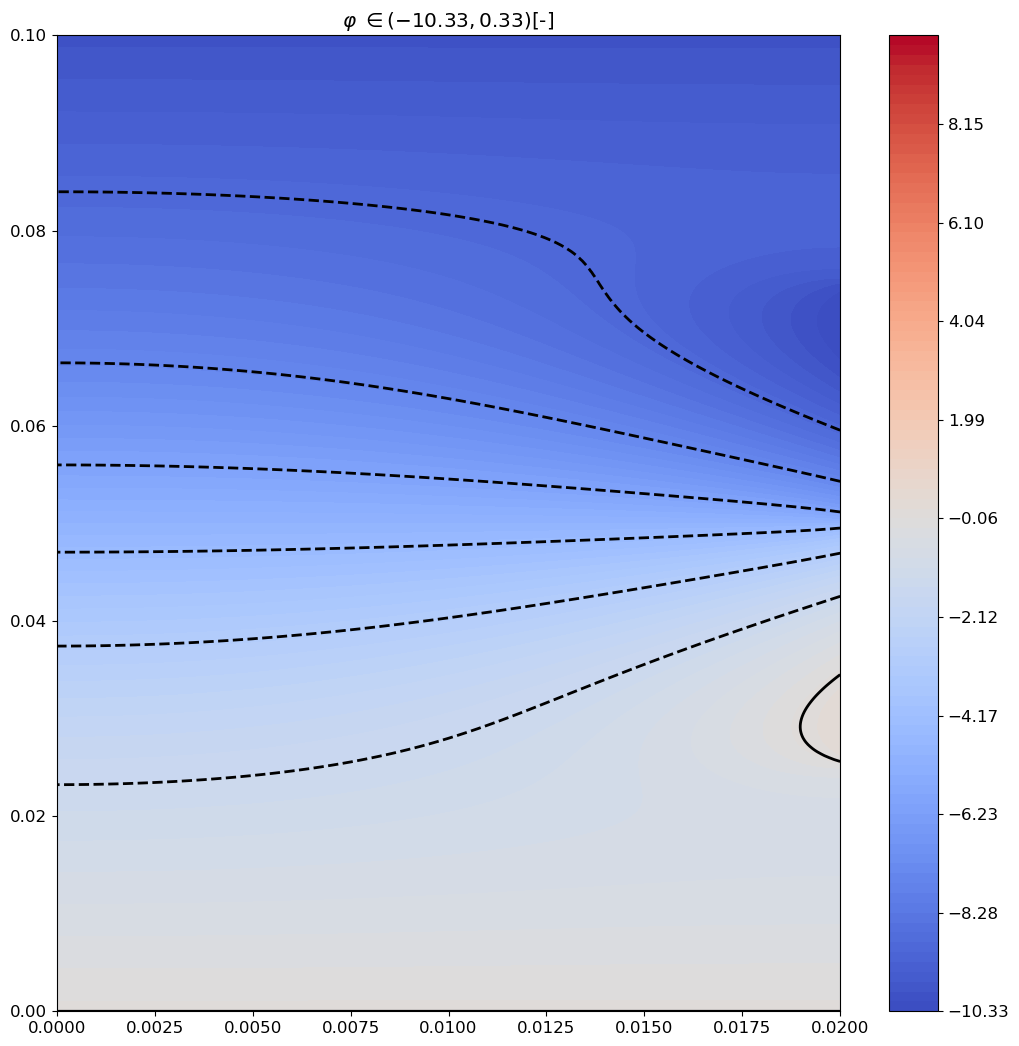

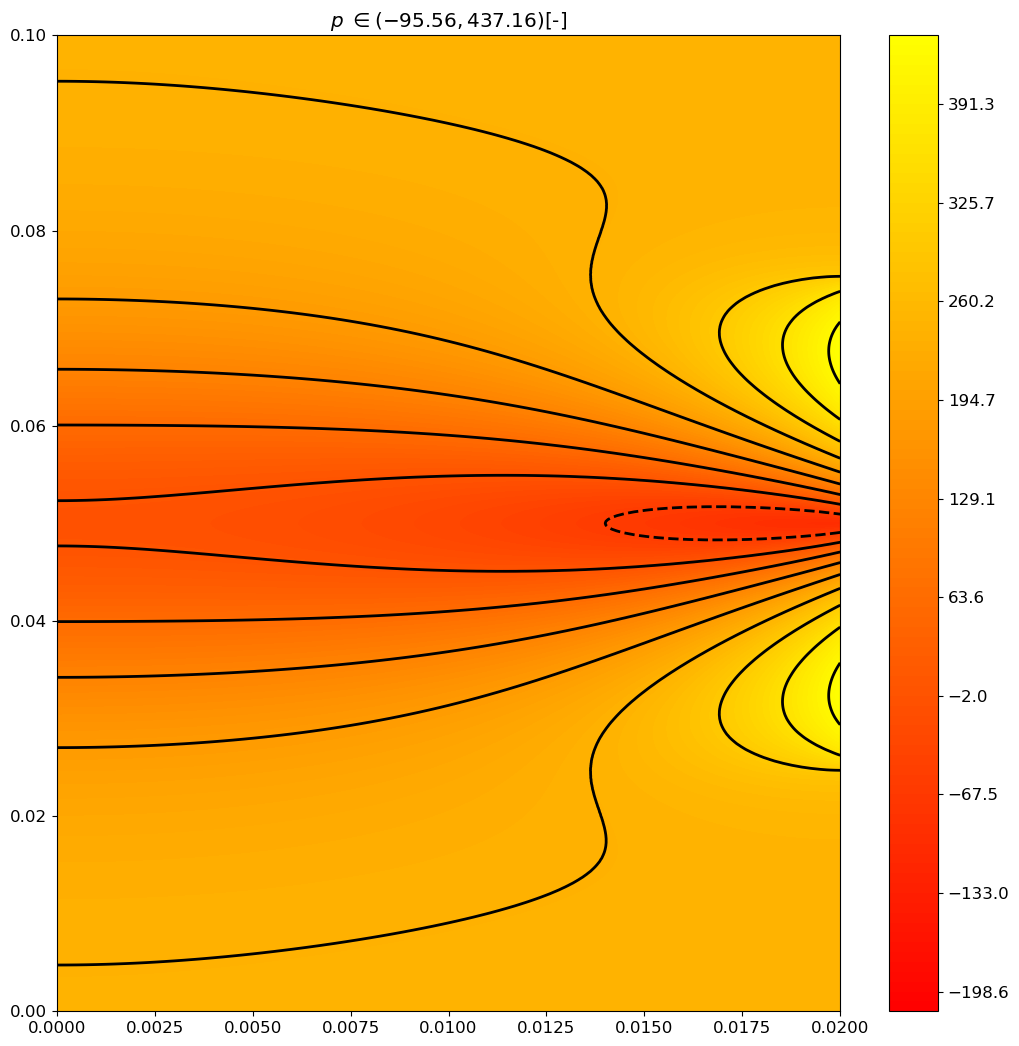

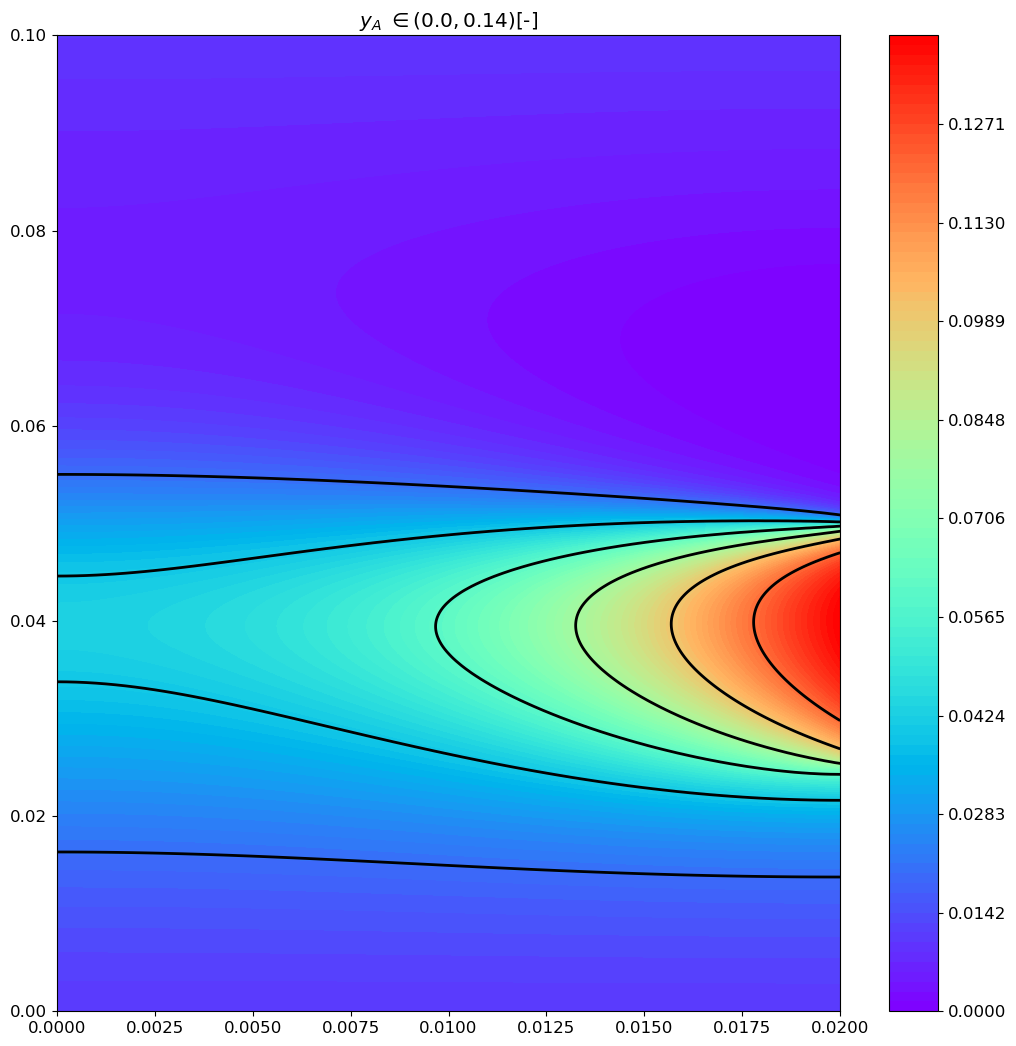

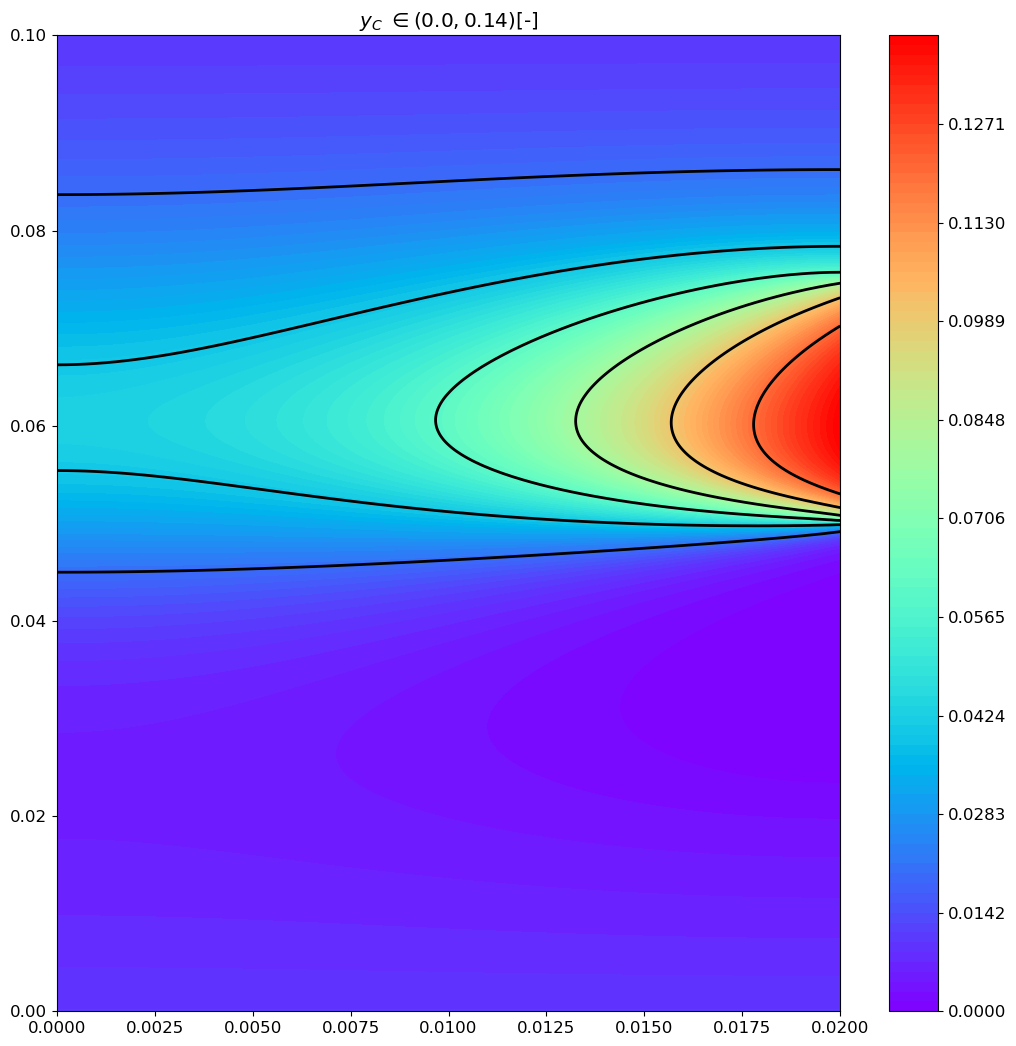

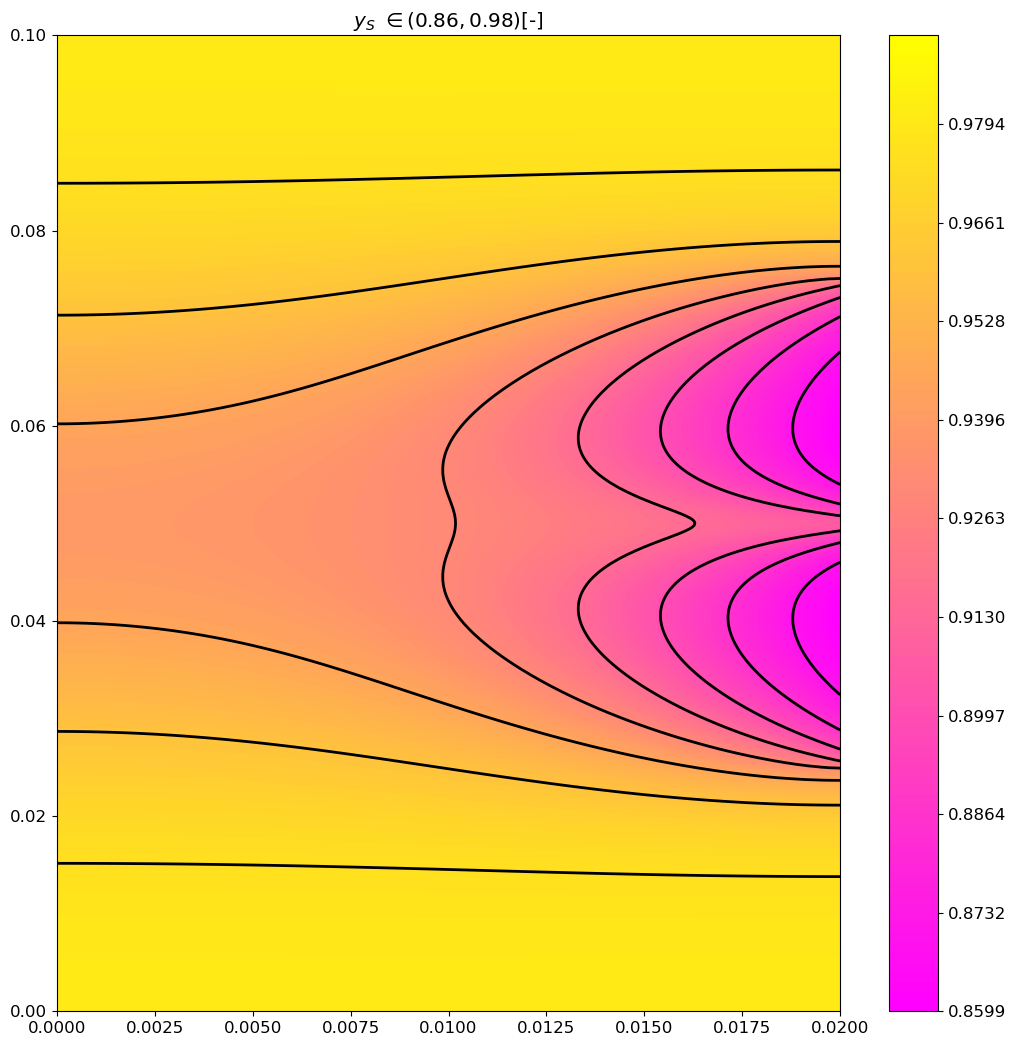

In [47]:
colorthemes = ['coolwarm', 'autumn', 'rainbow', 'rainbow', 'spring']
levels_colorbar = 100
levels_contour = 8#20
vmap_concentrations = np.linspace(np.min([np.min(y_A_Diode), np.min(y_C_Diode)]), np.max([np.max(y_A_Diode), np.max(y_C_Diode)]), levels_colorbar)
vmap_solvent = np.linspace(np.min(y_S_Diode), np.max(y_S_Diode), levels_colorbar)
vmap_potential = np.linspace(np.min(phi_Diode), np.max(phi_Diode), levels_colorbar)
vmap_pressure = np.linspace(np.min(p_Diode), np.max(p_Diode), levels_colorbar)
vmaps = [vmap_potential, vmap_pressure, vmap_concentrations, vmap_concentrations, vmap_solvent]
properties_Diode = [phi_Diode, p_Diode, y_A_Diode, y_C_Diode, y_S_Diode]
properties_Diode_counter = [0, 1, 2, 3, 4]
properties_Diode_title = ['$\\varphi$', '$p$', '$y_A$', '$y_C$', '$y_S$']

for bias_, bias_label in enumerate(['ForwardBias', 'NoBias', 'BackwardBias']): # iterate over biases
    for property, property_title, colortheme_, vmap_ in zip(properties_Diode, properties_Diode_title, colorthemes, vmaps): # iterate over properties
        fig, ax = plt.subplots(figsize=(3.54*3, 3.54*3))
        c = ax.tricontourf(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=vmap_, cmap=colortheme_)
        cbar = fig.colorbar(c, ax=ax)
        ax.tricontour(x_Diode[bias_], y_Diode[bias_], property[bias_], levels=levels_contour, colors='k')
        ax.set_title(f'{property_title} $\in ({round(np.min(property[bias_]),2)},{round(np.max(property[bias_]), 2)})$[-]')
        ax.grid()
        fig.tight_layout()
        fig.savefig(f'{savefig_directory}/ElectrolyticDiode/ElectrolyticDiode_{bias_label}_{property_title}.pdf', bbox_inches='tight')
        fig.show()